# Leakage-aware supervised MLTSA rerun v4

This notebook is the interactive version of `run_improved_pipeline.py`.

Main safeguards:

1. One summarized sample per trajectory.
2. Nested stratified group cross-validation.
3. Regularized GBDT model selection inside the inner folds.
4. Out-of-fold trajectory-level performance and group-bootstrap confidence intervals.
5. Held-out permutation importance.
6. Retrospective UNK analysis on a common valid trajectory set.
7. OUT-class heterogeneity robustness check (label-score-filtered rerun), **plus** an
   out-of-sample check that scores the excluded borderline OUT trajectories with a
   model that never saw them, so "robust" isn't just "we deleted the hard cases".
8. Fisher-decorrelated feature ranking alongside permutation importance. The Fisher
   score is computed **inside the nested loop**, on the same selected window and the
   same held-out test fold as permutation importance -- not on the whole trajectory,
   not outside cross-validation. `RUN_FISHER_DECORRELATION` switch, on by default.
9. Label-permutation null baseline, so OOF accuracy is checked against chance rather
   than only reported on its own. `NULL_USE_FULL_GRID` switches between a fast
   narrow-candidate null and a slow but stricter full-grid null (identical search
   space as the real analysis, repeated per permutation).
10. **New:** a regression alternative (Section C2) that predicts `log(label_scores)`
    directly instead of collapsing OUT into one class, using the exact same nested
    window search as Section A.
11. **New:** Visualizations (Section E) are saved to `args.out_dir` as PNG files, not
    just shown inline.

Run the cells from top to bottom. Edit only the **Configuration** cell for a standard
rerun -- `args.path` must point at your real HDF5 file (the cell will fail fast with a
clear error if it doesn't).

**Known residual limitation (nesting cannot fix this by itself):** the candidate grids
used below (window sizes, ξ = CV_41 / CV_195, crop and band_frac values) were narrowed
down using earlier, non-nested exploratory runs (`run_fixed_pipeline.py`,
`run_unk_crop.py`, `run_unk_cv195.py`). Nesting the search here removes the leakage
*within* this notebook's evaluation, but it cannot retroactively de-bias which
candidates were put in the grid in the first place. Treat the numbers below as the
correct way to evaluate this candidate set, not as proof the candidate set was chosen
without hindsight. Confirming on a fresh batch of trajectories, or a grid fixed before
any peeking, is the next step for a strong claim.


### v4 corrections

- Output directory is fixed to `/mnt/data1/student/trypsin/yucheng/07.12/v4`.
- Fisher decorrelation now uses correlations from the same outer-fold held-out,
  fold-selected window or UNK feature matrices as the Fisher scores.
- Regression folds approximately stratify the continuous log-label-score range at
  group level, and Spearman correlation uses standard average ranks for ties.
- Regression output includes OOF MAE on the log-score scale.
- Plot titles are unique, preventing PNG files from overwriting one another.


We evaluated trajectory-level prediction of IN and OUT outcomes using nested cross-validation on 173 molecular dynamics trajectories, each represented by time-averaged collective variables within candidate windows. The fixed-window analysis achieved an out-of-fold balanced accuracy of 0.737, with a trajectory-bootstrap 95% confidence interval of 0.668 to 0.800, and an ROC AUC of 0.842. All five outer folds selected windows after frame 2037, indicating that the discriminative signal was concentrated in the late part of the trajectories. A full-grid label permutation test yielded an empirical p value of 0.01, supporting performance above chance. Restricting the analysis to committed OUT trajectories increased balanced accuracy to 0.761, while retrospective transition-region analysis achieved 0.717. Continuous regression of log label scores produced an OOF R² of 0.256 and a Spearman correlation of 0.527. CV_195 emerged repeatedly across classification, committed-OUT, and regression analyses. Overall, the results support robust late-stage discrimination between IN and OUT trajectories, while evidence for early prospective prediction remains limited.


In [1]:
import argparse
import json
import os
import sys
import time
import warnings
from collections import Counter
from dataclasses import asdict, dataclass
from typing import Dict, Iterable, List, Mapping, Optional, Sequence, Tuple

import h5py
import joblib
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
)
from scipy.stats import spearmanr
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_sample_weight


@dataclass(frozen=True)
class WindowSpec:
    start: int
    end: int
    size: int

    @property
    def key(self) -> str:
        return f"w_{self.start}_{self.end}"


@dataclass(frozen=True)
class UnkSpec:
    xi: int
    crop: int
    band_frac: float

    @property
    def key(self) -> str:
        bf = str(self.band_frac).replace(".", "p")
        return f"unk_xi{self.xi}_crop{self.crop}_bf{bf}"


MODEL_GRID: Tuple[Mapping[str, object], ...] = (
    {
        "n_estimators": 150,
        "learning_rate": 0.03,
        "max_depth": 1,
        "min_samples_leaf": 5,
        "subsample": 0.8,
    },
    {
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_samples_leaf": 10,
        "subsample": 0.8,
    },
)

# Same shrinkage/depth philosophy as MODEL_GRID, but for the Section C2 regression
# alternative (predicting log(label_scores) instead of classifying IN/OUT).
MODEL_GRID_REGRESSION: Tuple[Mapping[str, object], ...] = (
    {
        "n_estimators": 150,
        "learning_rate": 0.03,
        "max_depth": 1,
        "min_samples_leaf": 5,
        "subsample": 0.8,
    },
    {
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_samples_leaf": 10,
        "subsample": 0.8,
    },
)


## Utility and data-loading functions

In [2]:
def parse_csv_ints(value: str) -> List[int]:
    try:
        return [int(x.strip()) for x in value.split(",") if x.strip()]
    except ValueError as exc:
        raise argparse.ArgumentTypeError(str(exc)) from exc


def parse_csv_floats(value: str) -> List[float]:
    try:
        return [float(x.strip()) for x in value.split(",") if x.strip()]
    except ValueError as exc:
        raise argparse.ArgumentTypeError(str(exc)) from exc


def json_ready(obj):
    if isinstance(obj, np.ndarray):
        return json_ready(obj.tolist())
    if isinstance(obj, np.generic):
        return json_ready(obj.item())
    if isinstance(obj, float) and not np.isfinite(obj):
        return None
    if isinstance(obj, bytes):
        return obj.decode(errors="replace")
    if isinstance(obj, dict):
        return {str(k): json_ready(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [json_ready(v) for v in obj]
    return obj


def save_json(path: str, payload) -> None:
    with open(path, "w", encoding="utf-8") as handle:
        json.dump(json_ready(payload), handle, indent=2, sort_keys=False)


def decode_strings(values: np.ndarray) -> np.ndarray:
    return np.array(
        [v.decode(errors="replace") if isinstance(v, (bytes, np.bytes_)) else str(v) for v in values]
    )


def load_data(path: str):
    with h5py.File(path, "r") as handle:
        required = ("cv_data", "labels", "replica_ids")
        missing = [name for name in required if name not in handle]
        if missing:
            raise KeyError(f"Missing HDF5 datasets: {missing}")

        cv_data = handle["cv_data"][:]
        labels_raw = handle["labels"][:]
        groups = handle["replica_ids"][:]
        label_scores = handle["label_scores"][:] if "label_scores" in handle else None

        feature_names = None
        for key in ("feature_names", "cv_names", "features"):
            if key in handle and handle[key].shape[0] == cv_data.shape[2]:
                feature_names = decode_strings(handle[key][:])
                break

    if cv_data.ndim != 3:
        raise ValueError(f"cv_data must be 3-D, got shape {cv_data.shape}")
    if len(labels_raw) != cv_data.shape[0] or len(groups) != cv_data.shape[0]:
        raise ValueError("labels/replica_ids length does not match number of trajectories")
    if not np.isfinite(cv_data).all():
        bad = int((~np.isfinite(cv_data)).sum())
        raise ValueError(f"cv_data contains {bad} NaN/Inf values; clean or impute them first")

    labels = decode_strings(labels_raw)
    unknown = sorted(set(labels) - {"IN", "OUT"})
    if unknown:
        raise ValueError(f"Unexpected labels: {unknown}")
    y = np.array([0 if label == "IN" else 1 for label in labels], dtype=np.int64)

    if feature_names is None:
        feature_names = np.array([f"CV_{i}" for i in range(cv_data.shape[2])])

    return cv_data.astype(np.float32, copy=False), y, groups, label_scores, feature_names


def feasible_splits(y: np.ndarray, groups: np.ndarray, requested: int) -> int:
    counts = [len(np.unique(groups[y == cls])) for cls in np.unique(y)]
    n = min([requested, len(np.unique(groups)), *counts])
    if n < 2:
        raise ValueError(
            f"Grouped CV is impossible: unique groups per class={counts}, requested={requested}"
        )
    if n < requested:
        warnings.warn(
            f"Requested {requested} grouped splits but only {n} are feasible "
            f"(unique groups per class={counts}); silently reducing the fold count "
            "for this call. Downstream OOF/CI estimates rest on fewer folds than configured.",
            RuntimeWarning,
            stacklevel=2,
        )
    return int(n)


def grouped_splits(
    indices: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    requested: int,
    seed: int,
):
    n_splits = feasible_splits(y[indices], groups[indices], requested)
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    local = np.arange(len(indices))
    return [
        (indices[tr_local], indices[te_local])
        for tr_local, te_local in splitter.split(local, y[indices], groups[indices])
    ]


def feasible_splits_regression(groups: np.ndarray, requested: int) -> int:
    n = min(requested, len(np.unique(groups)))
    if n < 2:
        raise ValueError(
            f"Grouped regression CV is impossible: only {len(np.unique(groups))} "
            f"unique group(s) available, requested={requested}"
        )
    if n < requested:
        warnings.warn(
            f"Requested {requested} grouped regression splits but only {n} unique "
            "groups are available; reducing the fold count for this call.",
            RuntimeWarning,
            stacklevel=2,
        )
    return int(n)


def _regression_group_strata(
    indices: np.ndarray,
    target: np.ndarray,
    groups: np.ndarray,
    n_splits: int,
    max_bins: int = 5,
) -> Optional[np.ndarray]:
    """Return approximately equal-count target strata at the group level.

    The continuous target is summarized once per group, groups are ordered by that
    target, and then assigned to rank-quantile bins. This keeps low, middle, and
    high log(label_scores) represented across folds without leaking any feature
    information. When there are too few groups to form at least two useful bins,
    return None and let the caller use shuffled group chunks as a fallback.
    """
    local_groups = groups[indices]
    unique_groups, inverse = np.unique(local_groups, return_inverse=True)
    n_groups = len(unique_groups)
    if n_groups < 2 * n_splits:
        return None

    group_target = np.array(
        [float(np.mean(target[indices][inverse == i])) for i in range(n_groups)],
        dtype=np.float64,
    )
    n_bins = min(max_bins, n_groups // n_splits)
    if n_bins < 2:
        return None

    order = np.argsort(group_target, kind="mergesort")
    group_bins = np.empty(n_groups, dtype=np.int64)
    group_bins[order] = np.minimum(
        (np.arange(n_groups, dtype=np.int64) * n_bins) // n_groups,
        n_bins - 1,
    )
    return group_bins[inverse]


def grouped_kfold_regression(
    indices: np.ndarray,
    target: np.ndarray,
    groups: np.ndarray,
    requested: int,
    seed: int,
):
    """Grouped regression CV with approximate target-distribution stratification.

    Rank-quantile strata are built from the continuous target at the group level,
    then passed to StratifiedGroupKFold. This avoids folds that accidentally hold
    nearly all extreme label_scores. A shuffled group-chunk fallback is retained
    for very small datasets where meaningful target strata cannot be formed.
    """
    n_splits = feasible_splits_regression(groups[indices], requested)
    strata = _regression_group_strata(indices, target, groups, n_splits)

    if strata is not None and len(np.unique(strata)) >= 2:
        splitter = StratifiedGroupKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=seed,
        )
        local = np.arange(len(indices))
        return [
            (indices[tr_local], indices[te_local])
            for tr_local, te_local in splitter.split(
                local,
                strata,
                groups[indices],
            )
        ]

    unique_groups = np.unique(groups[indices])
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(unique_groups)
    fold_groups = np.array_split(shuffled, n_splits)
    splits = []
    for fold in fold_groups:
        te_mask = np.isin(groups[indices], fold)
        te = indices[te_mask]
        tr = indices[~te_mask]
        splits.append((tr, te))
    return splits


## Trajectory-level feature extraction

In [3]:
def build_window_specs(n_frames: int, sizes: Sequence[int], n_positions: int) -> List[WindowSpec]:
    specs: List[WindowSpec] = []
    seen = set()
    for size in sizes:
        if size < 1 or size > n_frames:
            raise ValueError(f"Invalid window size {size} for {n_frames} frames")
        starts = np.linspace(0, n_frames - size, n_positions, dtype=int)
        for start in starts:
            spec = WindowSpec(int(start), int(start + size - 1), int(size))
            if spec.key not in seen:
                specs.append(spec)
                seen.add(spec.key)
    full = WindowSpec(0, n_frames - 1, n_frames)
    if full.key not in seen:
        specs.append(full)
    return specs


def window_features(cv_data: np.ndarray, spec: WindowSpec, stride: int) -> np.ndarray:
    frames = cv_data[:, spec.start : spec.end + 1 : stride, :]
    if frames.shape[1] == 0:
        raise ValueError(f"Window {spec} has no frames after stride={stride}")
    return frames.mean(axis=1, dtype=np.float64).astype(np.float32)


def smooth_1d(values: np.ndarray, width: int) -> np.ndarray:
    if width <= 1:
        return values.astype(np.float64, copy=False)
    kernel = np.ones(width, dtype=np.float64) / width
    left = width // 2
    right = width - 1 - left
    padded = np.pad(values, (left, right), mode="edge")
    return np.convolve(padded, kernel, mode="valid")


def unk_features(
    cv_data: np.ndarray,
    spec: UnkSpec,
    ts_win: int,
    end_win: int,
    smooth_width: int,
    min_unk_frames: int,
    span_epsilon: float,
) -> Tuple[np.ndarray, np.ndarray, Dict[str, object]]:
    """Return one mean feature vector per trajectory and a validity mask.

    This is retrospective: xi_end from the same trajectory is needed to define
    signed progress. It is suitable for transition-signature analysis, not for a
    prospective predictor that must operate before the endpoint is known.
    """
    n_traj, n_frames, n_cvs = cv_data.shape
    if not 0 <= spec.xi < n_cvs:
        raise IndexError(f"xi={spec.xi} outside [0, {n_cvs - 1}]")
    if spec.crop >= n_frames - end_win:
        raise ValueError(f"crop={spec.crop} leaves no usable trajectory")

    keep_features = np.ones(n_cvs, dtype=bool)
    keep_features[spec.xi] = False
    X = np.full((n_traj, n_cvs - 1), np.nan, dtype=np.float32)
    valid = np.zeros(n_traj, dtype=bool)
    unk_lengths = np.zeros(n_traj, dtype=np.int64)
    spans = np.zeros(n_traj, dtype=np.float64)

    for j in range(n_traj):
        xi_raw = cv_data[j, :, spec.xi].astype(np.float64)
        xi = smooth_1d(xi_raw, smooth_width)
        # TS reference is always the actual start. Crop only excludes frames.
        xi_ts = float(xi_raw[:ts_win].mean())
        xi_end = float(xi_raw[-end_win:].mean())
        delta = xi_end - xi_ts
        spans[j] = abs(delta)
        if abs(delta) <= span_epsilon:
            continue

        progress = (xi - xi_ts) / delta
        middle = (progress > spec.band_frac) & (progress < 1.0 - spec.band_frac)
        middle[: spec.crop] = False
        middle[-end_win:] = False
        idx = np.flatnonzero(middle)
        unk_lengths[j] = len(idx)
        if len(idx) < min_unk_frames:
            continue

        X[j] = cv_data[j, idx, :][:, keep_features].mean(axis=0, dtype=np.float64)
        valid[j] = True

    diagnostics = {
        "xi": spec.xi,
        "crop": spec.crop,
        "band_frac": spec.band_frac,
        "n_valid": int(valid.sum()),
        "valid_fraction": float(valid.mean()),
        "unk_length_median_valid": float(np.median(unk_lengths[valid])) if valid.any() else None,
        "unk_length_min_valid": int(unk_lengths[valid].min()) if valid.any() else None,
        "unk_length_max_valid": int(unk_lengths[valid].max()) if valid.any() else None,
        "span_min": float(spans.min()),
        "span_median": float(np.median(spans)),
        "span_max": float(spans.max()),
    }
    return X, valid, diagnostics


## Nested model selection and evaluation

In [4]:
def make_model(params: Mapping[str, object], seed: int) -> GradientBoostingClassifier:
    return GradientBoostingClassifier(random_state=seed, **dict(params))


def fit_model(X: np.ndarray, y: np.ndarray, params: Mapping[str, object], seed: int):
    model = make_model(params, seed)
    sample_weight = compute_sample_weight(class_weight="balanced", y=y)
    model.fit(X, y, sample_weight=sample_weight)
    return model


def candidate_signature(candidate_key: str, model_index: int) -> str:
    return f"{candidate_key}|m{model_index}"


def select_best(
    feature_cache: Mapping[str, np.ndarray],
    candidate_keys: Sequence[str],
    train_indices: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    inner_splits: int,
    seed: int,
    screen_top_k: int,
) -> Tuple[str, int, List[Dict[str, object]]]:
    splits = grouped_splits(train_indices, y, groups, inner_splits, seed)
    table: List[Dict[str, object]] = []

    # Stage 1 screens every candidate with the most conservative model.
    screen_rows: List[Dict[str, object]] = []
    for candidate_key in candidate_keys:
        X = feature_cache[candidate_key]
        params = MODEL_GRID[0]
        scores = []
        train_scores = []
        for fold_index, (tr, va) in enumerate(splits):
            model = fit_model(X[tr], y[tr], params, seed + fold_index)
            train_scores.append(balanced_accuracy_score(y[tr], model.predict(X[tr])))
            scores.append(balanced_accuracy_score(y[va], model.predict(X[va])))
        row = {
            "candidate_key": candidate_key,
            "model_index": 0,
            "inner_test_mean": float(np.mean(scores)),
            "inner_test_std": float(np.std(scores)),
            "inner_train_mean": float(np.mean(train_scores)),
            "params": dict(params),
            "search_stage": "screen",
        }
        screen_rows.append(row)
        table.append(row)

    ranked_keys = [
        row["candidate_key"]
        for row in sorted(
            screen_rows,
            key=lambda row: (row["inner_test_mean"], -row["inner_test_std"]),
            reverse=True,
        )[: max(1, min(screen_top_k, len(screen_rows)))]
    ]

    # Stage 2 tries the remaining regularized models only on screened candidates.
    for candidate_key in ranked_keys:
        X = feature_cache[candidate_key]
        for model_index, params in enumerate(MODEL_GRID[1:], start=1):
            scores = []
            train_scores = []
            for fold_index, (tr, va) in enumerate(splits):
                model = fit_model(X[tr], y[tr], params, seed + 1000 * model_index + fold_index)
                train_scores.append(balanced_accuracy_score(y[tr], model.predict(X[tr])))
                scores.append(balanced_accuracy_score(y[va], model.predict(X[va])))
            table.append(
                {
                    "candidate_key": candidate_key,
                    "model_index": model_index,
                    "inner_test_mean": float(np.mean(scores)),
                    "inner_test_std": float(np.std(scores)),
                    "inner_train_mean": float(np.mean(train_scores)),
                    "params": dict(params),
                    "search_stage": "refine",
                }
            )

    # Prefer higher validation score, then lower variability, then lower train gap.
    best = max(
        table,
        key=lambda row: (
            row["inner_test_mean"],
            -row["inner_test_std"],
            -(row["inner_train_mean"] - row["inner_test_mean"]),
        ),
    )
    return str(best["candidate_key"]), int(best["model_index"]), table


def cluster_bootstrap_ci(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    groups: np.ndarray,
    n_bootstrap: int,
    seed: int,
) -> Tuple[Optional[float], Optional[float]]:
    if n_bootstrap <= 0:
        return None, None
    rng = np.random.default_rng(seed)
    unique_groups = np.unique(groups)
    group_to_indices = {group: np.flatnonzero(groups == group) for group in unique_groups}
    scores = []
    for _ in range(n_bootstrap):
        sampled_groups = rng.choice(unique_groups, size=len(unique_groups), replace=True)
        idx = np.concatenate([group_to_indices[group] for group in sampled_groups])
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(balanced_accuracy_score(y_true[idx], y_pred[idx]))
    if not scores:
        return None, None
    return float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))


def fisher_scores(
    y: np.ndarray,
    reference_features: np.ndarray,
    eps_scale: float = 0.01,
) -> np.ndarray:
    """Per-CV Fisher discriminant ratio, scale-invariant per the fixes memo.

    eps must live in the same (squared/variance) units as the denominator it is
    added to -- `eps_scale * std_pooled` on its own is a *linear*-scale quantity
    and does not belong added to `var0 + var1`. Squaring it fixes the unit
    mismatch while keeping the "eps = 1% of a CV's scale" intent from the memo.
    """
    y = np.asarray(y)
    mean0 = reference_features[y == 0].mean(axis=0)
    mean1 = reference_features[y == 1].mean(axis=0)
    var0 = reference_features[y == 0].var(axis=0)
    var1 = reference_features[y == 1].var(axis=0)
    std_pooled = reference_features.std(axis=0)
    eps = (eps_scale * std_pooled) ** 2
    return (mean1 - mean0) ** 2 / (var0 + var1 + eps)


def nested_evaluate(
    analysis_name: str,
    feature_cache: Mapping[str, np.ndarray],
    candidate_keys: Sequence[str],
    indices: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    n_features_original: int,
    feature_maps: Mapping[str, np.ndarray],
    outer_splits: int,
    inner_splits: int,
    seed: int,
    permutation_repeats: int,
    bootstrap_repeats: int,
    screen_top_k: int,
    run_fisher_decorrelation: bool = False,
    fisher_eps_scale: float = 0.01,
) -> Dict[str, object]:
    outer = grouped_splits(indices, y, groups, outer_splits, seed)
    oof_pred = np.full(len(y), -1, dtype=np.int64)
    oof_prob = np.full(len(y), np.nan, dtype=np.float64)
    fold_rows: List[Dict[str, object]] = []
    perm_sum = np.zeros(n_features_original, dtype=np.float64)
    perm_count = np.zeros(n_features_original, dtype=np.int64)
    fisher_sum = np.zeros(n_features_original, dtype=np.float64)
    fisher_count = np.zeros(n_features_original, dtype=np.int64)
    corr_sum = np.zeros((n_features_original, n_features_original), dtype=np.float64)
    corr_count = np.zeros((n_features_original, n_features_original), dtype=np.int64)

    for fold_index, (tr, te) in enumerate(outer):
        selected_key, model_index, inner_table = select_best(
            feature_cache,
            candidate_keys,
            tr,
            y,
            groups,
            inner_splits,
            seed + 100 * (fold_index + 1),
            screen_top_k,
        )
        params = MODEL_GRID[model_index]
        X = feature_cache[selected_key]
        model = fit_model(X[tr], y[tr], params, seed + 10_000 + fold_index)
        train_pred = model.predict(X[tr])
        test_pred = model.predict(X[te])
        test_prob = model.predict_proba(X[te])[:, 1]
        oof_pred[te] = test_pred
        oof_prob[te] = test_prob

        train_score = balanced_accuracy_score(y[tr], train_pred)
        test_score = balanced_accuracy_score(y[te], test_pred)
        test_auc = roc_auc_score(y[te], test_prob) if len(np.unique(y[te])) == 2 else None

        perm_mean_original = np.full(n_features_original, np.nan, dtype=np.float64)
        fisher_mean_original = np.full(n_features_original, np.nan, dtype=np.float64)
        two_classes_in_test = len(np.unique(y[te])) == 2

        if permutation_repeats > 0 and two_classes_in_test:
            perm = permutation_importance(
                model,
                X[te],
                y[te],
                scoring="balanced_accuracy",
                n_repeats=permutation_repeats,
                random_state=seed + 20_000 + fold_index,
                n_jobs=1,
            )
            fmap = feature_maps[selected_key]
            perm_mean_original[fmap] = perm.importances_mean
            valid_perm = np.isfinite(perm_mean_original)
            perm_sum[valid_perm] += perm_mean_original[valid_perm]
            perm_count[valid_perm] += 1

        if run_fisher_decorrelation and two_classes_in_test:
            # Computed on X[te]/y[te] -- the SAME selected window and the SAME
            # held-out rows permutation importance uses. This is what fixes both
            # "wrong time segment" (it's the actual selected window, not the
            # full 2500-frame trajectory) and "no fold stability" (it's folded
            # and held-out just like permutation importance, not one global pass
            # over every trajectory including the ones that will later be test
            # data in other folds).
            fmap = feature_maps[selected_key]
            fold_fisher = fisher_scores(y[te], X[te], eps_scale=fisher_eps_scale)
            fisher_mean_original[fmap] = fold_fisher
            valid_fisher = np.isfinite(fisher_mean_original)
            fisher_sum[valid_fisher] += fisher_mean_original[valid_fisher]
            fisher_count[valid_fisher] += 1

            # Correlation used by the decorrelation pass comes from the same
            # selected feature matrix and the same held-out trajectories. For
            # UNK candidates, fmap restores the reduced matrix to original CV ids.
            with np.errstate(invalid="ignore", divide="ignore"):
                fold_abs_corr = np.abs(np.corrcoef(X[te], rowvar=False))
            fold_abs_corr = np.atleast_2d(fold_abs_corr)
            finite_corr = np.isfinite(fold_abs_corr)
            ix = np.ix_(fmap, fmap)
            corr_sum[ix] += np.where(finite_corr, fold_abs_corr, 0.0)
            corr_count[ix] += finite_corr.astype(np.int64)

        fold_rows.append(
            {
                "fold": fold_index,
                "selected_key": selected_key,
                "model_index": model_index,
                "params": dict(params),
                "train_balanced_accuracy": float(train_score),
                "test_balanced_accuracy": float(test_score),
                "test_roc_auc": None if test_auc is None else float(test_auc),
                "n_train": int(len(tr)),
                "n_test": int(len(te)),
                "train_test_gap": float(train_score - test_score),
                "test_indices": te.tolist(),
                "inner_search": inner_table,
                "permutation_importance_original": perm_mean_original.tolist(),
                "fisher_score_original": fisher_mean_original.tolist(),
            }
        )
        print(
            f"[{analysis_name}] outer fold {fold_index + 1}/{len(outer)}: "
            f"selected={selected_key}, model=m{model_index}, "
            f"train={train_score:.3f}, test={test_score:.3f}",
            flush=True,
        )

    missing = indices[oof_pred[indices] < 0]
    if len(missing):
        raise RuntimeError(f"OOF predictions missing for indices {missing.tolist()}")

    overall_bacc = balanced_accuracy_score(y[indices], oof_pred[indices])
    overall_auc = roc_auc_score(y[indices], oof_prob[indices]) if len(np.unique(y[indices])) == 2 else None
    ci_low, ci_high = cluster_bootstrap_ci(
        y[indices], oof_pred[indices], groups[indices], bootstrap_repeats, seed + 30_000
    )
    cm = confusion_matrix(y[indices], oof_pred[indices], labels=[0, 1])

    mean_perm = np.full(n_features_original, np.nan, dtype=np.float64)
    assessed = perm_count > 0
    mean_perm[assessed] = perm_sum[assessed] / perm_count[assessed]

    mean_fisher = np.full(n_features_original, np.nan, dtype=np.float64)
    fisher_assessed = fisher_count > 0
    mean_fisher[fisher_assessed] = fisher_sum[fisher_assessed] / fisher_count[fisher_assessed]

    mean_abs_corr = np.full(
        (n_features_original, n_features_original),
        np.nan,
        dtype=np.float64,
    )
    corr_assessed = corr_count > 0
    mean_abs_corr[corr_assessed] = corr_sum[corr_assessed] / corr_count[corr_assessed]

    return {
        "analysis": analysis_name,
        "n_trajectories": int(len(indices)),
        "outer_fold_test_mean": float(np.mean([r["test_balanced_accuracy"] for r in fold_rows])),
        "outer_fold_test_std": float(np.std([r["test_balanced_accuracy"] for r in fold_rows])),
        "outer_fold_train_mean": float(np.mean([r["train_balanced_accuracy"] for r in fold_rows])),
        "oof_balanced_accuracy": float(overall_bacc),
        "oof_balanced_accuracy_cluster_bootstrap_95ci": [ci_low, ci_high],
        "oof_roc_auc": None if overall_auc is None else float(overall_auc),
        "oof_confusion_matrix_labels_IN_OUT": cm.tolist(),
        "selected_key_counts": dict(Counter(row["selected_key"] for row in fold_rows)),
        "selected_model_counts": dict(Counter(f"m{row['model_index']}" for row in fold_rows)),
        "oof_prediction": oof_pred.tolist(),
        "oof_probability_OUT": oof_prob.tolist(),
        "mean_heldout_permutation_importance": mean_perm.tolist(),
        "permutation_importance_fold_count": perm_count.tolist(),
        "mean_heldout_fisher_score": mean_fisher.tolist(),
        "fisher_score_fold_count": fisher_count.tolist(),
        "_mean_heldout_abs_correlation": mean_abs_corr,
        "folds": fold_rows,
    }


def top_features(importances: Sequence[float], feature_names: np.ndarray, n: int = 20):
    imp = np.asarray(importances, dtype=np.float64)
    finite = np.flatnonzero(np.isfinite(imp))
    order = finite[np.argsort(imp[finite])[::-1]]
    return [
        {"rank": rank, "index": int(i), "name": str(feature_names[i]), "importance": float(imp[i])}
        for rank, i in enumerate(order[:n], start=1)
    ]


def annotate_redundancy(
    top: List[Dict[str, object]],
    mean_abs_correlation: np.ndarray,
    threshold: float = 0.8,
) -> List[Dict[str, object]]:
    """Flag top-ranked features redundant with a higher-ranked feature.

    `mean_abs_correlation` is averaged across outer-fold held-out matrices after
    each fold has selected its own window or UNK configuration. The annotation
    therefore refers to the same temporal/segment representation used for the
    held-out importance calculation, rather than a full-trajectory surrogate.
    """
    if not top:
        return top
    corr = np.asarray(mean_abs_correlation, dtype=np.float64)
    annotated = []
    for rank, row in enumerate(top):
        i = int(row["index"])
        best_corr = 0.0
        redundant_with = None
        for prior_rank in range(rank):
            j = int(top[prior_rank]["index"])
            value = corr[i, j]
            if np.isfinite(value) and value >= threshold and value > best_corr:
                best_corr = float(value)
                redundant_with = top[prior_rank]["name"]
        new_row = dict(row)
        new_row["max_abs_corr_with_higher_ranked"] = (
            best_corr if redundant_with is not None else None
        )
        new_row["likely_redundant_with"] = redundant_with
        annotated.append(new_row)
    return annotated


def label_permutation_null(
    feature_cache: Mapping[str, np.ndarray],
    candidate_keys: Sequence[str],
    indices: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    n_features_original: int,
    feature_maps: Mapping[str, np.ndarray],
    outer_splits: int,
    inner_splits: int,
    seed: int,
    screen_top_k: int,
    n_permutations: int,
    analysis_name: str,
) -> Dict[str, object]:
    """Rerun the same nested pipeline with trajectory labels shuffled.

    This answers a question the OOF metric alone cannot: is the observed OOF
    balanced accuracy actually above what an unrelated (shuffled-label)
    dataset would produce under the identical nested search? Permutation
    importance, the Fisher score, and the bootstrap CI are skipped per repeat
    purely for speed; only the OOF balanced accuracy is needed to build the
    null distribution. Labels are shuffled only within `indices`, so class
    balance is preserved.
    """
    rng = np.random.default_rng(seed)
    null_scores = np.zeros(n_permutations, dtype=np.float64)
    for p in range(n_permutations):
        y_shuffled = y.copy()
        shuffled_local = rng.permutation(y[indices])
        y_shuffled[indices] = shuffled_local
        result = nested_evaluate(
            analysis_name=f"{analysis_name}_null_{p}",
            feature_cache=feature_cache,
            candidate_keys=candidate_keys,
            indices=indices,
            y=y_shuffled,
            groups=groups,
            n_features_original=n_features_original,
            feature_maps=feature_maps,
            outer_splits=outer_splits,
            inner_splits=inner_splits,
            seed=seed + 1000 * (p + 1),
            permutation_repeats=0,
            bootstrap_repeats=0,
            screen_top_k=screen_top_k,
            run_fisher_decorrelation=False,
        )
        null_scores[p] = result["oof_balanced_accuracy"]
    return {
        "analysis": analysis_name,
        "n_permutations": int(n_permutations),
        "null_oof_balanced_accuracy_scores": null_scores.tolist(),
        "null_mean": float(null_scores.mean()),
        "null_std": float(null_scores.std()),
    }


def empirical_p_value(observed: float, null_scores: Sequence[float]) -> float:
    """One-sided empirical p-value: P(null >= observed)."""
    arr = np.asarray(null_scores, dtype=np.float64)
    return float((1 + np.sum(arr >= observed)) / (1 + len(arr)))


def fisher_decorrelated_ranking(
    scores: Sequence[float],
    mean_abs_correlation: np.ndarray,
    feature_names: np.ndarray,
    n: int = 20,
    corr_threshold: float = 0.8,
    exclude_indices: Optional[Iterable[int]] = None,
) -> List[Dict[str, object]]:
    """Greedy re-ranking of a precomputed per-CV score (fixes memo section 2.4
    and 4): take CVs in descending score order, skipping any CV that is highly
    correlated (|corr| >= corr_threshold) with a CV already accepted.

    `scores` should already be the held-out, per-fold-averaged Fisher score
    from `nested_evaluate` (`mean_heldout_fisher_score`). The supplied absolute
    correlation matrix is also averaged from the SAME selected window/config
    and the SAME held-out test folds. This function only performs the greedy
    decorrelation step; it does not recompute Fisher scores or correlations.
    """
    scores = np.asarray(scores, dtype=np.float64)
    exclude = set(int(i) for i in (exclude_indices or []))
    finite = np.isfinite(scores)
    order = np.argsort(np.where(finite, scores, -np.inf))[::-1]
    corr = np.asarray(mean_abs_correlation, dtype=np.float64)

    selected: List[int] = []
    for i in order:
        i = int(i)
        if i in exclude or not finite[i]:
            continue
        if any(np.isfinite(corr[i, j]) and corr[i, j] >= corr_threshold for j in selected):
            continue
        selected.append(i)
        if len(selected) >= n:
            break

    return [
        {
            "rank": rank,
            "index": i,
            "name": str(feature_names[i]),
            "fisher_score": float(scores[i]),
        }
        for rank, i in enumerate(selected, start=1)
    ]


# ---------------------------------------------------------------------------
# Section C2 machinery: same nested-CV skeleton, regressing log(label_scores)
# instead of classifying IN/OUT (fixes memo section 1.4, option 2).
# ---------------------------------------------------------------------------
def make_regressor(params: Mapping[str, object], seed: int) -> GradientBoostingRegressor:
    return GradientBoostingRegressor(random_state=seed, **dict(params))


def fit_regressor(X: np.ndarray, y: np.ndarray, params: Mapping[str, object], seed: int):
    model = make_regressor(params, seed)
    model.fit(X, y)
    return model


def select_best_regression(
    feature_cache: Mapping[str, np.ndarray],
    candidate_keys: Sequence[str],
    train_indices: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    inner_splits: int,
    seed: int,
    screen_top_k: int,
) -> Tuple[str, int, List[Dict[str, object]]]:
    splits = grouped_kfold_regression(train_indices, y, groups, inner_splits, seed)
    table: List[Dict[str, object]] = []

    screen_rows: List[Dict[str, object]] = []
    for candidate_key in candidate_keys:
        X = feature_cache[candidate_key]
        params = MODEL_GRID_REGRESSION[0]
        scores = []
        for fold_index, (tr, va) in enumerate(splits):
            model = fit_regressor(X[tr], y[tr], params, seed + fold_index)
            scores.append(r2_score(y[va], model.predict(X[va])))
        row = {
            "candidate_key": candidate_key,
            "model_index": 0,
            "inner_r2_mean": float(np.mean(scores)),
            "inner_r2_std": float(np.std(scores)),
            "params": dict(params),
            "search_stage": "screen",
        }
        screen_rows.append(row)
        table.append(row)

    ranked_keys = [
        row["candidate_key"]
        for row in sorted(
            screen_rows,
            key=lambda row: (row["inner_r2_mean"], -row["inner_r2_std"]),
            reverse=True,
        )[: max(1, min(screen_top_k, len(screen_rows)))]
    ]

    for candidate_key in ranked_keys:
        X = feature_cache[candidate_key]
        for model_index, params in enumerate(MODEL_GRID_REGRESSION[1:], start=1):
            scores = []
            for fold_index, (tr, va) in enumerate(splits):
                model = fit_regressor(X[tr], y[tr], params, seed + 1000 * model_index + fold_index)
                scores.append(r2_score(y[va], model.predict(X[va])))
            table.append(
                {
                    "candidate_key": candidate_key,
                    "model_index": model_index,
                    "inner_r2_mean": float(np.mean(scores)),
                    "inner_r2_std": float(np.std(scores)),
                    "params": dict(params),
                    "search_stage": "refine",
                }
            )

    best = max(table, key=lambda row: (row["inner_r2_mean"], -row["inner_r2_std"]))
    return str(best["candidate_key"]), int(best["model_index"]), table


def spearman_corr(a: np.ndarray, b: np.ndarray) -> float:
    """Spearman correlation with standard average-rank handling for ties."""
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    if len(a) < 2:
        return float("nan")
    result = spearmanr(a, b, nan_policy="omit")
    value = result.statistic
    return float(value) if np.isfinite(value) else float("nan")


def cluster_bootstrap_ci_regression(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    groups: np.ndarray,
    n_bootstrap: int,
    seed: int,
) -> Tuple[Optional[float], Optional[float]]:
    if n_bootstrap <= 0:
        return None, None
    rng = np.random.default_rng(seed)
    unique_groups = np.unique(groups)
    group_to_indices = {group: np.flatnonzero(groups == group) for group in unique_groups}
    scores = []
    for _ in range(n_bootstrap):
        sampled_groups = rng.choice(unique_groups, size=len(unique_groups), replace=True)
        idx = np.concatenate([group_to_indices[group] for group in sampled_groups])
        if len(idx) < 2 or np.var(y_true[idx]) == 0:
            continue
        scores.append(r2_score(y_true[idx], y_pred[idx]))
    if not scores:
        return None, None
    return float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))


def nested_evaluate_regression(
    analysis_name: str,
    feature_cache: Mapping[str, np.ndarray],
    candidate_keys: Sequence[str],
    indices: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    n_features_original: int,
    feature_maps: Mapping[str, np.ndarray],
    outer_splits: int,
    inner_splits: int,
    seed: int,
    permutation_repeats: int,
    bootstrap_repeats: int,
    screen_top_k: int,
) -> Dict[str, object]:
    """Same nested-CV skeleton as `nested_evaluate`, but regressing a continuous
    target (log label_scores) instead of classifying IN/OUT. Reframes the
    question as "which CVs predict how far the ligand ended up", sidestepping
    the OUT-class heterogeneity problem instead of filtering around it.
    """
    outer = grouped_kfold_regression(indices, y, groups, outer_splits, seed)
    oof_pred = np.full(len(y), np.nan, dtype=np.float64)
    fold_rows: List[Dict[str, object]] = []
    perm_sum = np.zeros(n_features_original, dtype=np.float64)
    perm_count = np.zeros(n_features_original, dtype=np.int64)
    corr_sum = np.zeros((n_features_original, n_features_original), dtype=np.float64)
    corr_count = np.zeros((n_features_original, n_features_original), dtype=np.int64)

    for fold_index, (tr, te) in enumerate(outer):
        selected_key, model_index, inner_table = select_best_regression(
            feature_cache,
            candidate_keys,
            tr,
            y,
            groups,
            inner_splits,
            seed + 100 * (fold_index + 1),
            screen_top_k,
        )
        params = MODEL_GRID_REGRESSION[model_index]
        X = feature_cache[selected_key]
        model = fit_regressor(X[tr], y[tr], params, seed + 10_000 + fold_index)
        train_pred = model.predict(X[tr])
        test_pred = model.predict(X[te])
        oof_pred[te] = test_pred

        train_r2 = r2_score(y[tr], train_pred)
        test_r2 = r2_score(y[te], test_pred)
        train_mae = mean_absolute_error(y[tr], train_pred)
        test_mae = mean_absolute_error(y[te], test_pred)

        fmap = feature_maps[selected_key]
        perm_mean_original = np.full(n_features_original, np.nan, dtype=np.float64)
        if permutation_repeats > 0 and len(te) >= 2:
            perm = permutation_importance(
                model,
                X[te],
                y[te],
                scoring="r2",
                n_repeats=permutation_repeats,
                random_state=seed + 20_000 + fold_index,
                n_jobs=1,
            )
            perm_mean_original[fmap] = perm.importances_mean
            valid_perm = np.isfinite(perm_mean_original)
            perm_sum[valid_perm] += perm_mean_original[valid_perm]
            perm_count[valid_perm] += 1

        if len(te) >= 2:
            with np.errstate(invalid="ignore", divide="ignore"):
                fold_abs_corr = np.abs(np.corrcoef(X[te], rowvar=False))
            fold_abs_corr = np.atleast_2d(fold_abs_corr)
            finite_corr = np.isfinite(fold_abs_corr)
            ix = np.ix_(fmap, fmap)
            corr_sum[ix] += np.where(finite_corr, fold_abs_corr, 0.0)
            corr_count[ix] += finite_corr.astype(np.int64)

        fold_rows.append(
            {
                "fold": fold_index,
                "selected_key": selected_key,
                "model_index": model_index,
                "params": dict(params),
                "train_r2": float(train_r2),
                "test_r2": float(test_r2),
                "train_mae": float(train_mae),
                "test_mae": float(test_mae),
                "n_train": int(len(tr)),
                "n_test": int(len(te)),
                "inner_search": inner_table,
                "permutation_importance_original": perm_mean_original.tolist(),
            }
        )
        print(
            f"[{analysis_name}] outer fold {fold_index + 1}/{len(outer)}: "
            f"selected={selected_key}, model=m{model_index}, "
            f"train_r2={train_r2:.3f}, test_r2={test_r2:.3f}",
            flush=True,
        )

    missing = indices[np.isnan(oof_pred[indices])]
    if len(missing):
        raise RuntimeError(f"OOF predictions missing for indices {missing.tolist()}")

    overall_r2 = r2_score(y[indices], oof_pred[indices])
    overall_mae = mean_absolute_error(y[indices], oof_pred[indices])
    overall_spearman = spearman_corr(y[indices], oof_pred[indices])
    ci_low, ci_high = cluster_bootstrap_ci_regression(
        y[indices], oof_pred[indices], groups[indices], bootstrap_repeats, seed + 30_000
    )

    mean_perm = np.full(n_features_original, np.nan, dtype=np.float64)
    assessed = perm_count > 0
    mean_perm[assessed] = perm_sum[assessed] / perm_count[assessed]

    mean_abs_corr = np.full(
        (n_features_original, n_features_original),
        np.nan,
        dtype=np.float64,
    )
    corr_assessed = corr_count > 0
    mean_abs_corr[corr_assessed] = corr_sum[corr_assessed] / corr_count[corr_assessed]

    return {
        "analysis": analysis_name,
        "n_trajectories": int(len(indices)),
        "outer_fold_test_r2_mean": float(np.mean([r["test_r2"] for r in fold_rows])),
        "outer_fold_test_r2_std": float(np.std([r["test_r2"] for r in fold_rows])),
        "outer_fold_train_r2_mean": float(np.mean([r["train_r2"] for r in fold_rows])),
        "outer_fold_test_mae_mean": float(np.mean([r["test_mae"] for r in fold_rows])),
        "outer_fold_test_mae_std": float(np.std([r["test_mae"] for r in fold_rows])),
        "oof_r2": float(overall_r2),
        "oof_mae_log_label_score": float(overall_mae),
        "oof_r2_cluster_bootstrap_95ci": [ci_low, ci_high],
        "oof_spearman_correlation": overall_spearman,
        "selected_key_counts": dict(Counter(row["selected_key"] for row in fold_rows)),
        "selected_model_counts": dict(Counter(f"m{row['model_index']}" for row in fold_rows)),
        "oof_prediction": oof_pred.tolist(),
        "mean_heldout_permutation_importance": mean_perm.tolist(),
        "permutation_importance_fold_count": perm_count.tolist(),
        "_mean_heldout_abs_correlation": mean_abs_corr,
        "folds": fold_rows,
    }


## Configuration

The defaults reproduce the improved command-line pipeline.  
For a quicker test, reduce `N_POSITIONS`, `PERMUTATION_REPEATS`, or `BOOTSTRAP_REPEATS`, or set `SKIP_UNK = True`.


In [5]:
from types import SimpleNamespace

args = SimpleNamespace(
    path="/mnt/data1/student/trypsin/h5_datasets/CV_database_4864_TS_variedDCDfreq_lmin2p6_lmax4p0.h5",
    out_dir="/mnt/data1/student/trypsin/yucheng/07.12/v4",
    seed=42,
    outer_splits=5,
    inner_splits=3,
    stride=10,
    window_sizes=[10, 50, 200],
    n_positions=12,
    xi_indices=[41, 195],
    crop_values=[0, 50, 200],
    band_fracs=[0.10, 0.20, 0.30],
    ts_win=5,
    end_win=5,
    smooth_width=5,
    min_unk_frames=5,
    span_epsilon=1e-8,
    permutation_repeats=10,
    screen_top_k=8,
    bootstrap_repeats=1000,
    skip_unk=False,
    # --- OUT-class heterogeneity robustness check (fixes memo, section 1.4) ---
    out_committed_threshold=5.0,   # keep IN + OUT with label_scores >= this value
    # --- correlation-redundancy annotation / Fisher-decorrelated ranking ---
    correlation_redundancy_threshold=0.8,
    run_fisher_decorrelation=True,
    fisher_eps_scale=0.01,
    fisher_top_n=20,
    # --- label-score regression alternative (fixes memo 1.4, option 2) ---
    run_label_score_regression=True,
    # --- label-permutation null baseline ---
    # 20 is only a quick sanity check (p-value resolution ~1/21 = 0.048, which
    # can't even resolve the p=0.05 line). For a number you'd report, use >= 99
    # (resolution 0.01) or 199+. 0 disables Section D entirely.
    null_permutations=99,
    null_use_full_grid=True,
    show_plots=True,
)

if args.stride < 1:
    raise ValueError("stride must be >= 1")
if args.n_positions < 2:
    raise ValueError("n_positions must be >= 2")
if args.null_permutations < 0:
    raise ValueError("null_permutations must be >= 0")
if not os.path.exists(args.path):
    raise FileNotFoundError(
        f"args.path does not exist: {args.path!r}. Edit the Configuration cell above "
        "to point at your real HDF5 dataset before running the rest of the notebook."
    )

os.makedirs(args.out_dir, exist_ok=True)
print(f"Outputs will be written to: {args.out_dir}")


Outputs will be written to: /mnt/data1/student/trypsin/yucheng/07.12/v4


In [6]:
# --- Defensive defaults for the new (Section C/C2/D) config fields -----------
# Falls back safely even if your Configuration cell above doesn't define these
# (e.g. because you pasted in your own args without the new fields).
OUT_COMMITTED_THRESHOLD = getattr(args, "out_committed_threshold", 5.0)
CORRELATION_REDUNDANCY_THRESHOLD = getattr(args, "correlation_redundancy_threshold", 0.8)
NULL_PERMUTATIONS = getattr(args, "null_permutations", 99)

# Switch: run the Fisher-decorrelated feature ranking alongside permutation
# importance. Computed per outer fold on the same selected window and the same
# held-out test rows as permutation importance -- see nested_evaluate().
RUN_FISHER_DECORRELATION = getattr(args, "run_fisher_decorrelation", True)
FISHER_EPS_SCALE = getattr(args, "fisher_eps_scale", 0.01)
FISHER_TOP_N = getattr(args, "fisher_top_n", 20)

# Switch: Section C2's regression alternative to OUT-class filtering.
RUN_LABEL_SCORE_REGRESSION = getattr(args, "run_label_score_regression", True)

# Switch: Section D's null baseline candidate space.
#   True  -> use the SAME full candidate grid as the real analysis for every
#            permutation (rigorous, matches Section A/B's search space exactly,
#            but null_permutations times slower than Section A/B alone).
#   False -> use only the window/config keys that were actually selected in
#            the real outer folds (fast, but the null model has less search
#            freedom than the real one, so the resulting p-value is optimistic).
NULL_USE_FULL_GRID = getattr(args, "null_use_full_grid", True)

if NULL_PERMUTATIONS < 0:
    raise ValueError("null_permutations must be >= 0")

print(
    f"out_committed_threshold={OUT_COMMITTED_THRESHOLD}  "
    f"correlation_redundancy_threshold={CORRELATION_REDUNDANCY_THRESHOLD}  "
    f"null_permutations={NULL_PERMUTATIONS}  "
    f"run_fisher_decorrelation={RUN_FISHER_DECORRELATION}  "
    f"run_label_score_regression={RUN_LABEL_SCORE_REGRESSION}  "
    f"null_use_full_grid={NULL_USE_FULL_GRID}"
)
if NULL_PERMUTATIONS > 0 and NULL_PERMUTATIONS < 99:
    print(
        f"null_permutations={NULL_PERMUTATIONS} is a quick sanity check only "
        f"(p-value resolution ~1/{NULL_PERMUTATIONS + 1:.0f} = "
        f"{1 / (NULL_PERMUTATIONS + 1):.3f}). Use >= 99 for a number you'd report."
    )
if NULL_PERMUTATIONS > 0 and NULL_USE_FULL_GRID:
    print(
        "null_use_full_grid=True: Section D will redo the FULL candidate search "
        f"{NULL_PERMUTATIONS} times. This is the rigorous setting but can be "
        "slow -- set args.null_use_full_grid = False for a quick/approximate check."
    )


out_committed_threshold=5.0  correlation_redundancy_threshold=0.8  null_permutations=99  run_fisher_decorrelation=True  run_label_score_regression=True  null_use_full_grid=True
null_use_full_grid=True: Section D will redo the FULL candidate search 99 times. This is the rigorous setting but can be slow -- set args.null_use_full_grid = False for a quick/approximate check.


## Load and validate the HDF5 dataset

In [7]:
started = time.time()

cv_data, y, groups, label_scores, feature_names = load_data(args.path)
n_traj, n_frames, n_cvs = cv_data.shape
indices = np.arange(n_traj, dtype=np.int64)

group_label_mixed = []
for group in np.unique(groups):
    labels_in_group = np.unique(y[groups == group])
    if len(labels_in_group) > 1:
        group_label_mixed.append(json_ready(group))

print(
    f"data={cv_data.shape}, IN={(y == 0).sum()}, OUT={(y == 1).sum()}, "
    f"unique_groups={len(np.unique(groups))}"
)
if group_label_mixed:
    print(
        f"warning: {len(group_label_mixed)} groups contain both labels; "
        "they remain grouped in CV"
    )

label_score_summary = None
if label_scores is not None:
    out_scores = label_scores[y == 1]
    n_committed = int((out_scores >= OUT_COMMITTED_THRESHOLD).sum())
    label_score_summary = {
        "IN_range": [float(label_scores[y == 0].min()), float(label_scores[y == 0].max())],
        "OUT_range": [float(out_scores.min()), float(out_scores.max())],
        "OUT_std": float(out_scores.std()),
        "out_committed_threshold": OUT_COMMITTED_THRESHOLD,
        "n_OUT_committed": n_committed,
        "n_OUT_borderline": int(len(out_scores) - n_committed),
    }
    print(
        f"label_scores: IN in [{label_score_summary['IN_range'][0]:.2f}, "
        f"{label_score_summary['IN_range'][1]:.2f}], "
        f"OUT in [{label_score_summary['OUT_range'][0]:.2f}, "
        f"{label_score_summary['OUT_range'][1]:.2f}] (std={label_score_summary['OUT_std']:.2f}); "
        f"{n_committed}/{len(out_scores)} OUT trajectories are >= "
        f"{OUT_COMMITTED_THRESHOLD} (committed)."
    )
else:
    print("label_scores not present; the OUT-class heterogeneity robustness "
          "check (Section C) will be skipped.")

metadata = {
    "path": args.path,
    "shape": list(cv_data.shape),
    "n_IN": int((y == 0).sum()),
    "n_OUT": int((y == 1).sum()),
    "n_unique_groups": int(len(np.unique(groups))),
    "mixed_label_groups": group_label_mixed,
    "label_scores_present": label_scores is not None,
    "label_score_summary": label_score_summary,
    "feature_names_loaded": not np.all(
        feature_names == np.array([f"CV_{i}" for i in range(n_cvs)])
    ),
    "arguments": vars(args),
    "model_grid": [dict(p) for p in MODEL_GRID],
    "candidate_grid_provenance_caveat": (
        "Window sizes, xi_indices, crop_values, and band_fracs in this config "
        "were narrowed down using earlier non-nested exploratory runs "
        "(run_fixed_pipeline.py, run_unk_crop.py, run_unk_cv195.py). The nested "
        "search below is unbiased conditional on this candidate grid, but the "
        "grid itself was informed by hindsight. See the intro cell."
    ),
}
save_json(os.path.join(args.out_dir, "run_metadata.json"), metadata)
metadata


data=(173, 2500, 274), IN=99, OUT=74, unique_groups=173
label_scores: IN in [2.40, 2.60], OUT in [4.05, 30.36] (std=4.54); 62/74 OUT trajectories are >= 5.0 (committed).


{'path': '/mnt/data1/student/trypsin/h5_datasets/CV_database_4864_TS_variedDCDfreq_lmin2p6_lmax4p0.h5',
 'shape': [173, 2500, 274],
 'n_IN': 99,
 'n_OUT': 74,
 'n_unique_groups': 173,
 'mixed_label_groups': [],
 'label_scores_present': True,
 'label_score_summary': {'IN_range': [2.3998506069, 2.5971198082],
  'OUT_range': [4.046728611, 30.3642864227],
  'OUT_std': 4.537653220323709,
  'out_committed_threshold': 5.0,
  'n_OUT_committed': 62,
  'n_OUT_borderline': 12},
 'feature_names_loaded': False,
 'arguments': {'path': '/mnt/data1/student/trypsin/h5_datasets/CV_database_4864_TS_variedDCDfreq_lmin2p6_lmax4p0.h5',
  'out_dir': '/mnt/data1/student/trypsin/yucheng/07.12/v4',
  'seed': 42,
  'outer_splits': 5,
  'inner_splits': 3,
  'stride': 10,
  'window_sizes': [10, 50, 200],
  'n_positions': 12,
  'xi_indices': [41, 195],
  'crop_values': [0, 50, 200],
  'band_fracs': [0.1, 0.2, 0.3],
  'ts_win': 5,
  'end_win': 5,
  'smooth_width': 5,
  'min_unk_frames': 5,
  'span_epsilon': 1e-08,
 

## A. Nested fixed-window analysis

Window and model selection occur only inside each outer training fold.  
The principal performance estimate is `fixed_result["oof_balanced_accuracy"]`.


In [8]:
window_specs = build_window_specs(
    n_frames, args.window_sizes, args.n_positions
)

window_cache: Dict[str, np.ndarray] = {}
window_map: Dict[str, np.ndarray] = {}
window_spec_by_key: Dict[str, WindowSpec] = {}

for spec in window_specs:
    window_cache[spec.key] = window_features(cv_data, spec, args.stride)
    window_map[spec.key] = np.arange(n_cvs, dtype=np.int64)
    window_spec_by_key[spec.key] = spec

fixed_result = nested_evaluate(
    analysis_name="fixed_window",
    feature_cache=window_cache,
    candidate_keys=list(window_cache),
    indices=indices,
    y=y,
    groups=groups,
    n_features_original=n_cvs,
    feature_maps=window_map,
    outer_splits=args.outer_splits,
    inner_splits=args.inner_splits,
    seed=args.seed,
    permutation_repeats=args.permutation_repeats,
    bootstrap_repeats=args.bootstrap_repeats,
    screen_top_k=args.screen_top_k,
    run_fisher_decorrelation=RUN_FISHER_DECORRELATION,
    fisher_eps_scale=FISHER_EPS_SCALE,
)

fixed_result["window_specs"] = {
    key: asdict(spec) for key, spec in window_spec_by_key.items()
}
fixed_mean_abs_corr = fixed_result.pop("_mean_heldout_abs_correlation")
fixed_result["feature_correlation_reference"] = (
    "Mean absolute CV correlation across outer-fold held-out matrices, using "
    "each fold's selected fixed window."
)
fixed_result["top_heldout_permutation_features"] = annotate_redundancy(
    top_features(fixed_result["mean_heldout_permutation_importance"], feature_names),
    fixed_mean_abs_corr,
    threshold=CORRELATION_REDUNDANCY_THRESHOLD,
)
fixed_result["fisher_decorrelated_top_features"] = (
    fisher_decorrelated_ranking(
        fixed_result["mean_heldout_fisher_score"], fixed_mean_abs_corr, feature_names,
        n=FISHER_TOP_N, corr_threshold=CORRELATION_REDUNDANCY_THRESHOLD,
    )
    if RUN_FISHER_DECORRELATION else None
)
save_json(
    os.path.join(args.out_dir, "fixed_window_nested_results.json"),
    fixed_result,
)

print(
    "Fixed-window nested OOF balanced accuracy:",
    round(fixed_result["oof_balanced_accuracy"], 4),
)
print(
    "Cluster-bootstrap 95% CI:",
    fixed_result["oof_balanced_accuracy_cluster_bootstrap_95ci"],
)
print("Selected windows across outer folds:")
fixed_result["selected_key_counts"]


[fixed_window] outer fold 1/5: selected=w_2090_2289, model=m0, train=0.917, test=0.755
[fixed_window] outer fold 2/5: selected=w_2263_2272, model=m0, train=0.940, test=0.667
[fixed_window] outer fold 3/5: selected=w_2490_2499, model=m1, train=1.000, test=0.889
[fixed_window] outer fold 4/5: selected=w_2450_2499, model=m0, train=0.935, test=0.675
[fixed_window] outer fold 5/5: selected=w_2037_2046, model=m0, train=0.925, test=0.712
Fixed-window nested OOF balanced accuracy: 0.7369
Cluster-bootstrap 95% CI: [0.6677019953221278, 0.7999270140428677]
Selected windows across outer folds:


{'w_2090_2289': 1,
 'w_2263_2272': 1,
 'w_2490_2499': 1,
 'w_2450_2499': 1,
 'w_2037_2046': 1}

### Top held-out permutation features (and a Fisher-decorrelated ranking)

Two independent rankings, side by side:

- `permutation_importance`: held-out permutation importance, annotated with `max_abs_corr_with_higher_ranked` where a feature is highly correlated with a higher-ranked one (flagged, not removed).
- `fisher_decorrelated`: a *re-ranked* list built from a scale-invariant Fisher discriminant score with a greedy decorrelation pass, so every entry is (by construction) not redundant with the ones above it.

If the two lists mostly agree, that is stronger evidence than either alone.


In [9]:
{
    "permutation_importance": fixed_result["top_heldout_permutation_features"],
    "fisher_decorrelated": fixed_result["fisher_decorrelated_top_features"],
}

{'permutation_importance': [{'rank': 1,
   'index': 195,
   'name': 'CV_195',
   'importance': 0.01976089188589187,
   'max_abs_corr_with_higher_ranked': None,
   'likely_redundant_with': None},
  {'rank': 2,
   'index': 230,
   'name': 'CV_230',
   'importance': 0.009392857142857139,
   'max_abs_corr_with_higher_ranked': None,
   'likely_redundant_with': None},
  {'rank': 3,
   'index': 198,
   'name': 'CV_198',
   'importance': 0.008142857142857132,
   'max_abs_corr_with_higher_ranked': 0.8687482766846756,
   'likely_redundant_with': 'CV_195'},
  {'rank': 4,
   'index': 67,
   'name': 'CV_67',
   'importance': 0.006769841269841273,
   'max_abs_corr_with_higher_ranked': None,
   'likely_redundant_with': None},
  {'rank': 5,
   'index': 120,
   'name': 'CV_120',
   'importance': 0.005625,
   'max_abs_corr_with_higher_ranked': None,
   'likely_redundant_with': None},
  {'rank': 6,
   'index': 186,
   'name': 'CV_186',
   'importance': 0.005392857142857137,
   'max_abs_corr_with_higher_r

## Refit a final deployable fixed-window model

This model is fitted on all trajectories. Use the nested out-of-fold metrics above when reporting performance.


In [10]:
final_window_key, final_model_index, final_window_search = select_best(
    window_cache,
    list(window_cache),
    indices,
    y,
    groups,
    args.outer_splits,
    args.seed + 40_000,
    args.screen_top_k,
)

final_window_model = fit_model(
    window_cache[final_window_key],
    y,
    MODEL_GRID[final_model_index],
    args.seed + 41_000,
)

final_window_bundle = {
    "model": final_window_model,
    "window": asdict(window_spec_by_key[final_window_key]),
    "stride": args.stride,
    "summary": "per-CV mean across the selected window",
    "model_params": dict(MODEL_GRID[final_model_index]),
    "feature_names": feature_names.tolist(),
    "label_mapping": {"IN": 0, "OUT": 1},
}
joblib.dump(
    final_window_bundle,
    os.path.join(args.out_dir, "fixed_window_final_model.joblib"),
)

final_selection = {
    "selected_key": final_window_key,
    "selected_window": asdict(window_spec_by_key[final_window_key]),
    "selected_model_index": final_model_index,
    "selected_model_params": dict(MODEL_GRID[final_model_index]),
    "full_data_grouped_search": final_window_search,
    "warning": (
        "The joblib model is a full-data refit. "
        "Report nested OOF metrics as performance."
    ),
}
save_json(
    os.path.join(args.out_dir, "fixed_window_final_selection.json"),
    final_selection,
)
final_selection["selected_window"], final_selection["selected_model_params"]


({'start': 2450, 'end': 2499, 'size': 50},
 {'n_estimators': 150,
  'learning_rate': 0.03,
  'max_depth': 1,
  'min_samples_leaf': 5,
  'subsample': 0.8})

## B. Retrospective UNK-signature analysis

This analysis uses each trajectory endpoint to define progress. It is appropriate for retrospective transition-signature discovery. It is not an endpoint-free early predictor.


In [11]:
unk_result = None

if args.skip_unk:
    print("UNK analysis skipped.")
else:
    unk_cache_all: Dict[str, np.ndarray] = {}
    unk_valid: Dict[str, np.ndarray] = {}
    unk_maps: Dict[str, np.ndarray] = {}
    unk_specs: Dict[str, UnkSpec] = {}
    unk_diagnostics: Dict[str, object] = {}

    for xi in args.xi_indices:
        if not 0 <= xi < n_cvs:
            raise IndexError(f"xi={xi} outside [0, {n_cvs - 1}]")
        for crop in args.crop_values:
            for band_frac in args.band_fracs:
                if not 0.0 < band_frac < 0.5:
                    raise ValueError(
                        f"band_frac must be in (0, 0.5), got {band_frac}"
                    )
                spec = UnkSpec(int(xi), int(crop), float(band_frac))
                X, valid, diagnostics = unk_features(
                    cv_data,
                    spec,
                    ts_win=args.ts_win,
                    end_win=args.end_win,
                    smooth_width=args.smooth_width,
                    min_unk_frames=args.min_unk_frames,
                    span_epsilon=args.span_epsilon,
                )
                unk_cache_all[spec.key] = X
                unk_valid[spec.key] = valid
                unk_maps[spec.key] = np.flatnonzero(
                    np.arange(n_cvs) != xi
                )
                unk_specs[spec.key] = spec
                unk_diagnostics[spec.key] = diagnostics

    # Every UNK configuration is scored on the same trajectories.
    common_valid = np.logical_and.reduce(
        [unk_valid[key] for key in unk_cache_all]
    )
    unk_indices = np.flatnonzero(common_valid)

    if len(unk_indices) < 20 or len(np.unique(y[unk_indices])) < 2:
        raise RuntimeError(
            f"Only {len(unk_indices)} trajectories are valid for every "
            "UNK configuration. Reduce min_unk_frames or compare fewer "
            "configurations."
        )

    print(
        f"UNK common valid set: {len(unk_indices)}/{n_traj} trajectories "
        f"(IN={(y[unk_indices] == 0).sum()}, "
        f"OUT={(y[unk_indices] == 1).sum()})"
    )

    unk_cache = {key: X for key, X in unk_cache_all.items()}
    for key, X in unk_cache.items():
        if not np.isfinite(X[unk_indices]).all():
            raise RuntimeError(
                f"Non-finite UNK features remain for candidate {key}"
            )

    unk_result = nested_evaluate(
        analysis_name="retrospective_UNK",
        feature_cache=unk_cache,
        candidate_keys=list(unk_cache),
        indices=unk_indices,
        y=y,
        groups=groups,
        n_features_original=n_cvs,
        feature_maps=unk_maps,
        outer_splits=args.outer_splits,
        inner_splits=args.inner_splits,
        seed=args.seed + 50_000,
        permutation_repeats=args.permutation_repeats,
        bootstrap_repeats=args.bootstrap_repeats,
        screen_top_k=args.screen_top_k,
        run_fisher_decorrelation=RUN_FISHER_DECORRELATION,
        fisher_eps_scale=FISHER_EPS_SCALE,
    )
    unk_result["common_valid_indices"] = unk_indices.tolist()
    unk_result["common_valid_fraction"] = float(common_valid.mean())
    unk_mean_abs_corr = unk_result.pop("_mean_heldout_abs_correlation")
    unk_result["feature_correlation_reference"] = (
        "Mean absolute CV correlation across outer-fold held-out matrices, using "
        "each fold's selected retrospective UNK configuration."
    )
    unk_result["specs"] = {
        key: asdict(spec) for key, spec in unk_specs.items()
    }
    unk_result["diagnostics"] = unk_diagnostics
    unk_result["top_heldout_permutation_features"] = annotate_redundancy(
        top_features(unk_result["mean_heldout_permutation_importance"], feature_names),
        unk_mean_abs_corr,
        threshold=CORRELATION_REDUNDANCY_THRESHOLD,
    )
    unk_result["fisher_decorrelated_top_features"] = (
        fisher_decorrelated_ranking(
            unk_result["mean_heldout_fisher_score"], unk_mean_abs_corr, feature_names,
            n=FISHER_TOP_N, corr_threshold=CORRELATION_REDUNDANCY_THRESHOLD,
            exclude_indices=args.xi_indices,
        )
        if RUN_FISHER_DECORRELATION else None
    )
    unk_result["interpretation_warning"] = (
        "Endpoint-derived segmentation makes this retrospective. "
        "Do not compare it as a deployable early predictor unless an "
        "endpoint-free progress coordinate is supplied."
    )
    save_json(
        os.path.join(args.out_dir, "unk_nested_results.json"),
        unk_result,
    )

    print(
        "Retrospective UNK nested OOF balanced accuracy:",
        round(unk_result["oof_balanced_accuracy"], 4),
    )
    print(
        "Cluster-bootstrap 95% CI:",
        unk_result[
            "oof_balanced_accuracy_cluster_bootstrap_95ci"
        ],
    )
    print("Selected UNK configurations across outer folds:")
    print(unk_result["selected_key_counts"])


UNK common valid set: 170/173 trajectories (IN=96, OUT=74)
[retrospective_UNK] outer fold 1/5: selected=unk_xi41_crop0_bf0p3, model=m0, train=0.911, test=0.775
[retrospective_UNK] outer fold 2/5: selected=unk_xi195_crop50_bf0p3, model=m1, train=1.000, test=0.819
[retrospective_UNK] outer fold 3/5: selected=unk_xi195_crop50_bf0p3, model=m1, train=1.000, test=0.725
[retrospective_UNK] outer fold 4/5: selected=unk_xi41_crop0_bf0p2, model=m0, train=0.905, test=0.636
[retrospective_UNK] outer fold 5/5: selected=unk_xi195_crop50_bf0p2, model=m1, train=1.000, test=0.669
Retrospective UNK nested OOF balanced accuracy: 0.7175
Cluster-bootstrap 95% CI: [0.6455702852893984, 0.786481469461469]
Selected UNK configurations across outer folds:
{'unk_xi41_crop0_bf0p3': 1, 'unk_xi195_crop50_bf0p3': 2, 'unk_xi41_crop0_bf0p2': 1, 'unk_xi195_crop50_bf0p2': 1}


### Top retrospective UNK features (and a Fisher-decorrelated ranking)

Same two-ranking comparison as Section A, with the ξ CV(s) excluded from both so nothing circular sneaks back in.


In [12]:
None if unk_result is None else {
    "permutation_importance": unk_result["top_heldout_permutation_features"],
    "fisher_decorrelated": unk_result["fisher_decorrelated_top_features"],
}

{'permutation_importance': [{'rank': 1,
   'index': 41,
   'name': 'CV_41',
   'importance': 0.019907407407407412,
   'max_abs_corr_with_higher_ranked': None,
   'likely_redundant_with': None},
  {'rank': 2,
   'index': 252,
   'name': 'CV_252',
   'importance': 0.014624999999999994,
   'max_abs_corr_with_higher_ranked': None,
   'likely_redundant_with': None},
  {'rank': 3,
   'index': 102,
   'name': 'CV_102',
   'importance': 0.011488888888888854,
   'max_abs_corr_with_higher_ranked': None,
   'likely_redundant_with': None},
  {'rank': 4,
   'index': 3,
   'name': 'CV_3',
   'importance': 0.009976608187134469,
   'max_abs_corr_with_higher_ranked': None,
   'likely_redundant_with': None},
  {'rank': 5,
   'index': 126,
   'name': 'CV_126',
   'importance': 0.00843418964076857,
   'max_abs_corr_with_higher_ranked': 0.8282329355753649,
   'likely_redundant_with': 'CV_41'},
  {'rank': 6,
   'index': 38,
   'name': 'CV_38',
   'importance': 0.007711111111111106,
   'max_abs_corr_with_hig

## C. Robustness check — filtering to strongly-committed OUT trajectories

`label_scores` for OUT trajectories span an order of magnitude (roughly 4-30 in the
reviewed dataset): "just crossed the threshold" and "fully unbound" are pooled into one
class. This reruns the fixed-window nested pipeline keeping only IN trajectories plus
OUT trajectories with `label_scores >= out_committed_threshold`, so borderline OUT
cases are excluded from training and evaluation. If the headline OOF accuracy from
Section A depends heavily on those borderline trajectories, this number will diverge
from it noticeably.


In [13]:
if label_scores is None:
    print("label_scores not present; skipping the OUT-class heterogeneity robustness check.")
    committed_result = None
else:
    committed_mask = (y == 0) | (label_scores >= OUT_COMMITTED_THRESHOLD)
    committed_indices = indices[committed_mask]
    borderline_indices = indices[~committed_mask]
    n_dropped = int(len(borderline_indices))
    print(
        f"Committed-OUT robustness check: keeping {len(committed_indices)}/{len(indices)} "
        f"trajectories (dropping {n_dropped} borderline OUT trajectories with "
        f"label_scores < {OUT_COMMITTED_THRESHOLD})."
    )
    if len(np.unique(y[committed_indices])) < 2:
        raise RuntimeError(
            "out_committed_threshold removed one entire class; lower the threshold."
        )

    committed_result = nested_evaluate(
        analysis_name="fixed_window_committed_out",
        feature_cache=window_cache,
        candidate_keys=list(window_cache),
        indices=committed_indices,
        y=y,
        groups=groups,
        n_features_original=n_cvs,
        feature_maps=window_map,
        outer_splits=args.outer_splits,
        inner_splits=args.inner_splits,
        seed=args.seed + 60_000,
        permutation_repeats=args.permutation_repeats,
        bootstrap_repeats=args.bootstrap_repeats,
        screen_top_k=args.screen_top_k,
        run_fisher_decorrelation=RUN_FISHER_DECORRELATION,
        fisher_eps_scale=FISHER_EPS_SCALE,
    )
    committed_mean_abs_corr = committed_result.pop("_mean_heldout_abs_correlation")
    committed_result["feature_correlation_reference"] = (
        "Mean absolute CV correlation across outer-fold held-out matrices, using "
        "each fold's selected committed-OUT fixed window."
    )
    committed_result["out_committed_threshold"] = OUT_COMMITTED_THRESHOLD
    committed_result["n_dropped_borderline_out"] = n_dropped
    committed_result["top_heldout_permutation_features"] = annotate_redundancy(
        top_features(committed_result["mean_heldout_permutation_importance"], feature_names),
        committed_mean_abs_corr,
        threshold=CORRELATION_REDUNDANCY_THRESHOLD,
    )
    committed_result["fisher_decorrelated_top_features"] = (
        fisher_decorrelated_ranking(
            committed_result["mean_heldout_fisher_score"], committed_mean_abs_corr, feature_names,
            n=FISHER_TOP_N, corr_threshold=CORRELATION_REDUNDANCY_THRESHOLD,
        )
        if RUN_FISHER_DECORRELATION else None
    )

    # --- Out-of-sample check on the trajectories we just excluded --------------
    # A committed-only model is only meaningfully "robust" if the borderline OUT
    # trajectories it never trained on still look OUT-ish to it. This is a
    # descriptive diagnostic (one fit on all committed data, no nesting, no CI)
    # -- it is not a performance estimate, just a sanity check on the filter.
    if len(borderline_indices) == 0:
        print("No borderline OUT trajectories were excluded; nothing to score out-of-sample.")
        committed_result["borderline_out_of_sample"] = None
    else:
        borderline_key, borderline_model_index, _ = select_best(
            window_cache, list(window_cache), committed_indices, y, groups,
            args.inner_splits, args.seed + 65_000, args.screen_top_k,
        )
        Xb = window_cache[borderline_key]
        borderline_model = fit_model(
            Xb[committed_indices], y[committed_indices],
            MODEL_GRID[borderline_model_index], args.seed + 65_001,
        )
        borderline_prob_out = borderline_model.predict_proba(Xb[borderline_indices])[:, 1]
        borderline_pred = (borderline_prob_out >= 0.5).astype(int)
        n_pred_out = int(borderline_pred.sum())
        committed_result["borderline_out_of_sample"] = {
            "window_key": borderline_key,
            "n_borderline": int(len(borderline_indices)),
            "n_predicted_OUT": n_pred_out,
            "n_predicted_IN": int(len(borderline_indices) - n_pred_out),
            "fraction_predicted_OUT": float(n_pred_out / len(borderline_indices)),
            "trajectory_index": borderline_indices.tolist(),
            "predicted_probability_OUT": borderline_prob_out.tolist(),
            "predicted_label": borderline_pred.tolist(),
            "label_scores": label_scores[borderline_indices].tolist(),
        }
        print(
            f"Borderline-OUT out-of-sample check: {n_pred_out}/{len(borderline_indices)} "
            f"borderline OUT trajectories are predicted OUT by the committed-only model "
            f"(window={borderline_key})."
        )
        print(
            "A fraction far below 1.0 means borderline OUT trajectories genuinely look "
            "IN-like to a model that never trained on them -- i.e. the committed/borderline "
            "split is not an arbitrary relabeling."
        )

    save_json(
        os.path.join(args.out_dir, "fixed_window_committed_out_results.json"),
        committed_result,
    )

    print(
        "Committed-OUT nested OOF balanced accuracy:",
        round(committed_result["oof_balanced_accuracy"], 4),
        " (full-OUT Section A value was",
        round(fixed_result["oof_balanced_accuracy"], 4), ")",
    )
    print(
        "Committed-OUT cluster-bootstrap 95% CI:",
        committed_result["oof_balanced_accuracy_cluster_bootstrap_95ci"],
    )
    print(
        "If these two OOF numbers diverge by a lot, the Section A headline result is "
        "sensitive to how the OUT class is defined and that should be reported alongside it."
    )


Committed-OUT robustness check: keeping 161/173 trajectories (dropping 12 borderline OUT trajectories with label_scores < 5.0).
[fixed_window_committed_out] outer fold 1/5: selected=w_2450_2499, model=m1, train=1.000, test=0.781
[fixed_window_committed_out] outer fold 2/5: selected=w_2450_2499, model=m1, train=1.000, test=0.836
[fixed_window_committed_out] outer fold 3/5: selected=w_2450_2499, model=m0, train=0.939, test=0.683
[fixed_window_committed_out] outer fold 4/5: selected=w_2090_2289, model=m0, train=0.938, test=0.718
[fixed_window_committed_out] outer fold 5/5: selected=w_2450_2499, model=m0, train=0.913, test=0.759
Borderline-OUT out-of-sample check: 9/12 borderline OUT trajectories are predicted OUT by the committed-only model (window=w_2300_2499).
A fraction far below 1.0 means borderline OUT trajectories genuinely look IN-like to a model that never trained on them -- i.e. the committed/borderline split is not an arbitrary relabeling.
Committed-OUT nested OOF balanced accur

## C2. Regression alternative — predicting log(label_scores)

The fixes memo's other option for the OUT-class heterogeneity problem (section 1.4):
instead of filtering the OUT class (Section C), regress `log(label_scores)` directly,
so "just crossed the threshold" and "fully unbound" aren't forced into one class in
the first place. This reframes the whole question as "which CVs predict how far the
ligand ended up" rather than a binary IN/OUT split.

Reuses the exact same window candidates, grouped outer/inner folds, and inner-search
machinery as Section A -- just with a `GradientBoostingRegressor` and R² / Spearman
instead of a classifier and balanced accuracy. Set
`args.run_label_score_regression = False` to skip. Runs only if `label_scores` is
present in the HDF5 file.


In [14]:
if not RUN_LABEL_SCORE_REGRESSION or label_scores is None:
    print(
        "Skipping the regression alternative "
        "(run_label_score_regression=False or label_scores missing)."
    )
    regression_result = None
else:
    log_label_scores = np.log(label_scores.astype(np.float64))
    regression_result = nested_evaluate_regression(
        analysis_name="label_score_regression",
        feature_cache=window_cache,
        candidate_keys=list(window_cache),
        indices=indices,
        y=log_label_scores,
        groups=groups,
        n_features_original=n_cvs,
        feature_maps=window_map,
        outer_splits=args.outer_splits,
        inner_splits=args.inner_splits,
        seed=args.seed + 90_000,
        permutation_repeats=args.permutation_repeats,
        bootstrap_repeats=args.bootstrap_repeats,
        screen_top_k=args.screen_top_k,
    )
    regression_mean_abs_corr = regression_result.pop("_mean_heldout_abs_correlation")
    regression_result["feature_correlation_reference"] = (
        "Mean absolute CV correlation across outer-fold held-out matrices, using "
        "each fold's selected regression fixed window."
    )
    regression_result["top_heldout_permutation_features"] = annotate_redundancy(
        top_features(regression_result["mean_heldout_permutation_importance"], feature_names),
        regression_mean_abs_corr,
        threshold=CORRELATION_REDUNDANCY_THRESHOLD,
    )
    save_json(
        os.path.join(args.out_dir, "label_score_regression_results.json"),
        regression_result,
    )

    print(
        "Regression (log label_scores) nested OOF R^2:",
        round(regression_result["oof_r2"], 4),
        " MAE(log score):", round(regression_result["oof_mae_log_label_score"], 4),
        " Spearman:", round(regression_result["oof_spearman_correlation"], 4),
    )
    print("R^2 cluster-bootstrap 95% CI:", regression_result["oof_r2_cluster_bootstrap_95ci"])
    print("Selected windows across outer folds:", regression_result["selected_key_counts"])
    print(
        "This reframes the question as 'which CVs predict how far the ligand ended up' "
        "instead of a binary IN/OUT split -- compare its top features against Section A's."
    )

[label_score_regression] outer fold 1/5: selected=w_1584_1593, model=m1, train_r2=0.863, test_r2=0.370
[label_score_regression] outer fold 2/5: selected=w_2300_2499, model=m0, train_r2=0.686, test_r2=0.119
[label_score_regression] outer fold 3/5: selected=w_1881_2080, model=m0, train_r2=0.687, test_r2=0.222
[label_score_regression] outer fold 4/5: selected=w_2090_2289, model=m0, train_r2=0.628, test_r2=0.232
[label_score_regression] outer fold 5/5: selected=w_2300_2499, model=m0, train_r2=0.670, test_r2=0.308
Regression (log label_scores) nested OOF R^2: 0.2557  MAE(log score): 0.3264  Spearman: 0.5269
R^2 cluster-bootstrap 95% CI: [0.15096151906223468, 0.35122486871956504]
Selected windows across outer folds: {'w_1584_1593': 1, 'w_2300_2499': 2, 'w_1881_2080': 1, 'w_2090_2289': 1}
This reframes the question as 'which CVs predict how far the ligand ended up' instead of a binary IN/OUT split -- compare its top features against Section A's.


### Top regression features

Held-out permutation importance for the regression model (scored by R², not balanced accuracy). Compare this ranking against Section A's -- CVs that show up in both are the strongest candidates.


In [15]:
None if regression_result is None else regression_result["top_heldout_permutation_features"]

[{'rank': 1,
  'index': 195,
  'name': 'CV_195',
  'importance': 0.02399547373574886,
  'max_abs_corr_with_higher_ranked': None,
  'likely_redundant_with': None},
 {'rank': 2,
  'index': 126,
  'name': 'CV_126',
  'importance': 0.023578148589143567,
  'max_abs_corr_with_higher_ranked': None,
  'likely_redundant_with': None},
 {'rank': 3,
  'index': 155,
  'name': 'CV_155',
  'importance': 0.020766927186146825,
  'max_abs_corr_with_higher_ranked': None,
  'likely_redundant_with': None},
 {'rank': 4,
  'index': 152,
  'name': 'CV_152',
  'importance': 0.01415561285284075,
  'max_abs_corr_with_higher_ranked': None,
  'likely_redundant_with': None},
 {'rank': 5,
  'index': 124,
  'name': 'CV_124',
  'importance': 0.011112750119557605,
  'max_abs_corr_with_higher_ranked': None,
  'likely_redundant_with': None},
 {'rank': 6,
  'index': 247,
  'name': 'CV_247',
  'importance': 0.010227636698088155,
  'max_abs_corr_with_higher_ranked': None,
  'likely_redundant_with': None},
 {'rank': 7,
  'in

## D. Null baseline — label-permutation control

Reruns the identical nested search with trajectory labels shuffled (`NULL_PERMUTATIONS` times) to build a chance-level distribution for the OOF balanced accuracy, then reports an empirical p-value.

`NULL_USE_FULL_GRID` controls how much search freedom each null repeat gets:

- `True` (default): every null repeat searches the **same full candidate grid** as Sections A/B. This is the rigorous setting -- it doesn't give the real analysis an unfair search-space advantage over its own null -- but it takes roughly `NULL_PERMUTATIONS`x as long as Section A/B.
- `False`: every null repeat only searches the window/config keys that were **actually selected** in the real outer folds. Much faster, but the null model has less freedom to fit noise than the real one, so the resulting p-value is optimistic (biased toward finding significance). Use this only for a quick sanity check, not for the number you report.

Set `args.null_permutations = 0` to skip this section entirely.


In [16]:
if NULL_PERMUTATIONS == 0:
    print("null_permutations=0; skipping the label-permutation null baseline.")
    fixed_null = None
else:
    if NULL_USE_FULL_GRID:
        null_fixed_candidates = list(window_cache)
        grid_note = "FULL candidate grid (matches Section A's search space exactly)"
    else:
        null_fixed_candidates = list(fixed_result["selected_key_counts"].keys()) or list(window_cache)[:5]
        grid_note = "narrow candidate set (only windows actually selected in Section A)"
    print(
        f"Running {NULL_PERMUTATIONS} label-shuffled null repeats over "
        f"{len(null_fixed_candidates)} candidate window(s) -- {grid_note}."
    )
    fixed_null = label_permutation_null(
        feature_cache=window_cache,
        candidate_keys=null_fixed_candidates,
        indices=indices,
        y=y,
        groups=groups,
        n_features_original=n_cvs,
        feature_maps=window_map,
        outer_splits=args.outer_splits,
        inner_splits=args.inner_splits,
        seed=args.seed + 70_000,
        screen_top_k=args.screen_top_k,
        n_permutations=NULL_PERMUTATIONS,
        analysis_name="fixed_window",
    )
    fixed_null["candidate_grid"] = "full" if NULL_USE_FULL_GRID else "narrow"
    fixed_null["observed_oof_balanced_accuracy"] = fixed_result["oof_balanced_accuracy"]
    fixed_null["p_value"] = empirical_p_value(
        fixed_result["oof_balanced_accuracy"], fixed_null["null_oof_balanced_accuracy_scores"]
    )
    save_json(os.path.join(args.out_dir, "fixed_window_null_baseline.json"), fixed_null)
    print(
        f"Null balanced accuracy: mean={fixed_null['null_mean']:.4f} "
        f"std={fixed_null['null_std']:.4f}  observed={fixed_null['observed_oof_balanced_accuracy']:.4f}  "
        f"empirical p-value={fixed_null['p_value']:.4f}"
    )

if NULL_PERMUTATIONS == 0 or unk_result is None:
    unk_null = None
else:
    if NULL_USE_FULL_GRID:
        null_unk_candidates = list(unk_cache)
        grid_note = "FULL candidate grid (matches Section B's search space exactly)"
    else:
        null_unk_candidates = list(unk_result["selected_key_counts"].keys()) or list(unk_cache)[:5]
        grid_note = "narrow candidate set (only configs actually selected in Section B)"
    print(
        f"Running {NULL_PERMUTATIONS} label-shuffled null repeats over "
        f"{len(null_unk_candidates)} candidate UNK config(s) -- {grid_note}."
    )
    unk_null = label_permutation_null(
        feature_cache=unk_cache,
        candidate_keys=null_unk_candidates,
        indices=unk_indices,
        y=y,
        groups=groups,
        n_features_original=n_cvs,
        feature_maps=unk_maps,
        outer_splits=args.outer_splits,
        inner_splits=args.inner_splits,
        seed=args.seed + 80_000,
        screen_top_k=args.screen_top_k,
        n_permutations=NULL_PERMUTATIONS,
        analysis_name="retrospective_UNK",
    )
    unk_null["candidate_grid"] = "full" if NULL_USE_FULL_GRID else "narrow"
    unk_null["observed_oof_balanced_accuracy"] = unk_result["oof_balanced_accuracy"]
    unk_null["p_value"] = empirical_p_value(
        unk_result["oof_balanced_accuracy"], unk_null["null_oof_balanced_accuracy_scores"]
    )
    save_json(os.path.join(args.out_dir, "unk_null_baseline.json"), unk_null)
    print(
        f"UNK null balanced accuracy: mean={unk_null['null_mean']:.4f} "
        f"std={unk_null['null_std']:.4f}  observed={unk_null['observed_oof_balanced_accuracy']:.4f}  "
        f"empirical p-value={unk_null['p_value']:.4f}"
    )

Running 99 label-shuffled null repeats over 37 candidate window(s) -- FULL candidate grid (matches Section A's search space exactly).
[fixed_window_null_0] outer fold 1/5: selected=w_1559_1608, model=m0, train=0.930, test=0.572
[fixed_window_null_0] outer fold 2/5: selected=w_0_49, model=m0, train=0.907, test=0.575
[fixed_window_null_0] outer fold 3/5: selected=w_890_939, model=m0, train=0.928, test=0.406
[fixed_window_null_0] outer fold 4/5: selected=w_0_49, model=m0, train=0.897, test=0.533
[fixed_window_null_0] outer fold 5/5: selected=w_0_9, model=m0, train=0.813, test=0.549
[fixed_window_null_1] outer fold 1/5: selected=w_0_9, model=m0, train=0.851, test=0.572
[fixed_window_null_1] outer fold 2/5: selected=w_1358_1367, model=m0, train=0.890, test=0.450
[fixed_window_null_1] outer fold 3/5: selected=w_1131_1140, model=m1, train=1.000, test=0.528
[fixed_window_null_1] outer fold 4/5: selected=w_0_199, model=m1, train=0.994, test=0.539
[fixed_window_null_1] outer fold 5/5: selected=w

## E. Visualizations

Every plot below is built only from numbers already computed above -- nothing is
recomputed. A few notes on what's safe to plot and what isn't:

- The window/UNK-config "sweep" plots use each outer fold's **inner-CV** scores
  (`fold["inner_search"]`), i.e. training-only scores used to pick a candidate --
  never the held-out test fold. This is the honest way to show "which configs looked
  competitive" without re-introducing the test-set-selection leakage from the original
  three scripts.
- The train-vs-test and confusion-matrix plots use the actual nested OOF results.
- Set `SHOW_PLOTS = False` below to skip this section (e.g. for a headless batch run).


In [17]:
%matplotlib inline
SHOW_PLOTS = getattr(args, "show_plots", True)

if SHOW_PLOTS:
    import re
    import matplotlib.pyplot as plt

    def _slug(text: str) -> str:
        return re.sub(r"[^a-zA-Z0-9]+", "_", text).strip("_").lower()

    def _save(fig, title: str) -> None:
        """Every plot below both displays inline AND is written to args.out_dir,
        so the figures survive even if the notebook itself isn't saved/exported."""
        path = os.path.join(args.out_dir, f"plot_{_slug(title)}.png")
        fig.savefig(path, dpi=150, bbox_inches="tight")

    def _parse_window_key(key: str):
        m = re.match(r"^w_(\d+)_(\d+)$", key)
        if not m:
            return None
        start, end = int(m.group(1)), int(m.group(2))
        return start, end, end - start + 1

    def _parse_unk_key(key: str):
        m = re.match(r"^unk_xi(\d+)_crop(\d+)_bf([0-9p]+)$", key)
        if not m:
            return None
        xi = int(m.group(1))
        crop = int(m.group(2))
        band_frac = float(m.group(3).replace("p", "."))
        return xi, crop, band_frac

    def aggregate_inner_scores(result: Dict[str, object]) -> Dict[str, float]:
        """Best inner-CV score per candidate key, averaged across outer folds.

        Only ever touches `inner_search` (training-fold-only scores), so this is
        safe to plot even though the outer test folds never influenced it.
        """
        per_key: Dict[str, List[float]] = {}
        for fold in result["folds"]:
            best_per_key: Dict[str, float] = {}
            for row in fold["inner_search"]:
                k = row["candidate_key"]
                if k not in best_per_key or row["inner_test_mean"] > best_per_key[k]:
                    best_per_key[k] = row["inner_test_mean"]
            for k, v in best_per_key.items():
                per_key.setdefault(k, []).append(v)
        return {k: float(np.mean(v)) for k, v in per_key.items()}

    def plot_window_sweep(result: Dict[str, object], title: str) -> None:
        scores = aggregate_inner_scores(result)
        rows = [(*_parse_window_key(k), s) for k, s in scores.items() if _parse_window_key(k)]
        if not rows:
            print(f"[{title}] no parseable window keys to plot.")
            return
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for size in sorted(set(r[2] for r in rows)):
            pts = sorted((r[0], r[3]) for r in rows if r[2] == size)
            xs, ys = zip(*pts)
            ax.plot(xs, ys, marker="o", label=f"size={size}")
        for key in result["selected_key_counts"]:
            parsed = _parse_window_key(key)
            if parsed:
                ax.axvline(parsed[0], color="grey", linestyle=":", alpha=0.4)
        ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="chance")
        ax.set_xlabel("window start frame")
        ax.set_ylabel("mean inner-CV balanced accuracy")
        ax.set_title(title)
        ax.legend(fontsize=8)
        fig.tight_layout()
        _save(fig, title)
        plt.show()

    def plot_unk_sweep(result: Dict[str, object], title: str) -> None:
        scores = aggregate_inner_scores(result)
        rows = [(*_parse_unk_key(k), s) for k, s in scores.items() if _parse_unk_key(k)]
        if not rows:
            print(f"[{title}] no parseable UNK keys to plot.")
            return
        fig, ax = plt.subplots(figsize=(8, 4.5))
        markers = ["o", "s", "^", "D", "v", "P"]
        combos = sorted(set((r[0], r[1]) for r in rows))
        for i, (xi, crop) in enumerate(combos):
            pts = sorted((r[2], r[3]) for r in rows if r[0] == xi and r[1] == crop)
            xs, ys = zip(*pts)
            ax.plot(xs, ys, marker=markers[i % len(markers)], label=f"xi=CV_{xi}, crop={crop}")
        ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="chance")
        ax.set_xlabel("band_frac")
        ax.set_ylabel("mean inner-CV balanced accuracy")
        ax.set_title(title)
        ax.legend(fontsize=7)
        fig.tight_layout()
        _save(fig, title)
        plt.show()

    def plot_fold_train_test(result: Dict[str, object], title: str) -> None:
        folds = result["folds"]
        idx = np.arange(len(folds))
        train = [f["train_balanced_accuracy"] for f in folds]
        test = [f["test_balanced_accuracy"] for f in folds]
        width = 0.35
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(idx - width / 2, train, width, label="train")
        ax.bar(idx + width / 2, test, width, label="test (OOF)")
        ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
        ax.set_xticks(idx)
        ax.set_xticklabels([f"fold {i}" for i in idx])
        ax.set_ylabel("balanced accuracy")
        ax.set_title(f"{title} -- per-fold train vs held-out test")
        ax.legend()
        fig.tight_layout()
        _save(fig, title)
        plt.show()

    def plot_null_distribution(null_result: Optional[Dict[str, object]], title: str) -> None:
        if null_result is None:
            print(f"[{title}] not computed (null_permutations=0 or section skipped).")
            return
        scores = null_result["null_oof_balanced_accuracy_scores"]
        observed = null_result["observed_oof_balanced_accuracy"]
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.hist(scores, bins=min(10, max(3, len(scores))), color="#888888", alpha=0.85,
                label="label-shuffled null")
        ax.axvline(observed, color="crimson", linewidth=2, label=f"observed = {observed:.3f}")
        ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="chance = 0.5")
        ax.set_xlabel("OOF balanced accuracy")
        ax.set_ylabel("count")
        p_val = null_result["p_value"]
        grid_mode = null_result["candidate_grid"]
        ax.set_title(f"{title}  (p={p_val:.3f}, grid={grid_mode})")
        ax.legend(fontsize=8)
        fig.tight_layout()
        _save(fig, title)
        plt.show()

    def plot_confusion(result: Dict[str, object], title: str) -> None:
        cm = np.array(result["oof_confusion_matrix_labels_IN_OUT"])
        fig, ax = plt.subplots(figsize=(4, 4))
        im = ax.imshow(cm, cmap="Blues")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2 else "black")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["IN", "OUT"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["IN", "OUT"])
        ax.set_xlabel("predicted"); ax.set_ylabel("true")
        ax.set_title(f"{title} -- OOF confusion matrix")
        fig.colorbar(im, fraction=0.046, pad=0.04)
        fig.tight_layout()
        _save(fig, title)
        plt.show()

    def plot_top_features_comparison(
        top_perm: Optional[List[Dict[str, object]]],
        top_fisher: Optional[List[Dict[str, object]]],
        title: str,
        n: int = 10,
    ) -> None:
        if not top_perm and not top_fisher:
            print(f"[{title}] no feature rankings to plot.")
            return
        fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
        if top_perm:
            rows = top_perm[:n][::-1]
            axes[0].barh([r["name"] for r in rows], [r["importance"] for r in rows], color="#4c72b0")
            axes[0].set_title("held-out permutation importance")
        else:
            axes[0].axis("off")
        if top_fisher:
            rows = top_fisher[:n][::-1]
            axes[1].barh([r["name"] for r in rows], [r["fisher_score"] for r in rows], color="#dd8452")
            axes[1].set_title("Fisher-decorrelated ranking")
        else:
            axes[1].axis("off")
        fig.suptitle(title)
        fig.tight_layout()
        _save(fig, title)
        plt.show()

    def plot_regression_scatter(result: Dict[str, object], indices_: np.ndarray, title: str) -> None:
        """Predicted vs. actual log(label_scores) for Section C2, colored by the
        true IN/OUT label so it's easy to see whether the regression is really
        adding information beyond the binary split it's meant to replace.
        """
        if result is None:
            print(f"[{title}] regression not run (run_label_score_regression=False "
                  "or label_scores missing).")
            return
        oof_pred = np.array(result["oof_prediction"])
        actual = log_label_scores[indices_]
        pred = oof_pred[indices_]
        colors = np.where(y[indices_] == 0, "#4c72b0", "#dd8452")
        fig, ax = plt.subplots(figsize=(5.5, 5.5))
        ax.scatter(actual, pred, c=colors, alpha=0.75, edgecolor="white", linewidth=0.5)
        lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
        ax.plot(lims, lims, color="black", linestyle="--", linewidth=1, label="perfect prediction")
        ax.set_xlabel("actual log(label_scores)")
        ax.set_ylabel("OOF predicted log(label_scores)")
        r2 = result["oof_r2"]
        rho = result["oof_spearman_correlation"]
        ax.set_title(f"{title}  (R^2={r2:.3f}, Spearman={rho:.3f})")
        from matplotlib.lines import Line2D
        handles = [
            Line2D([0], [0], marker="o", color="w", markerfacecolor="#4c72b0", label="IN", markersize=8),
            Line2D([0], [0], marker="o", color="w", markerfacecolor="#dd8452", label="OUT", markersize=8),
            Line2D([0], [0], color="black", linestyle="--", label="perfect prediction"),
        ]
        ax.legend(handles=handles, fontsize=8)
        fig.tight_layout()
        _save(fig, title)
        plt.show()
else:
    print("show_plots=False; skipping Section E.")

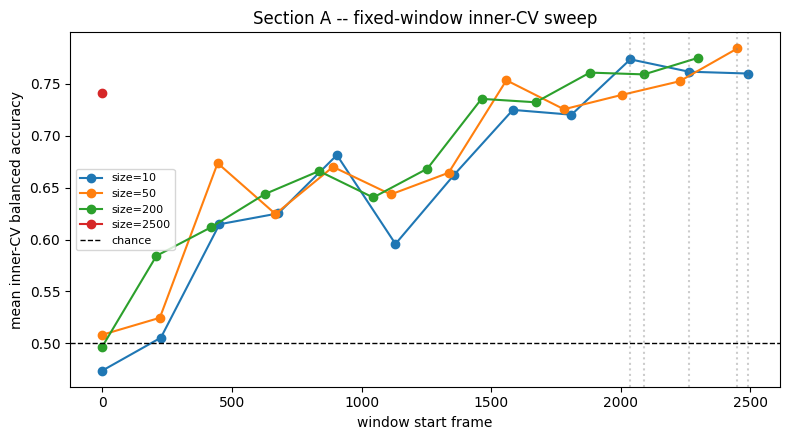

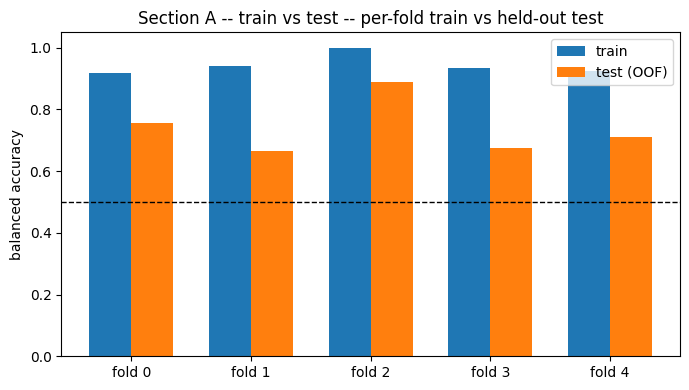

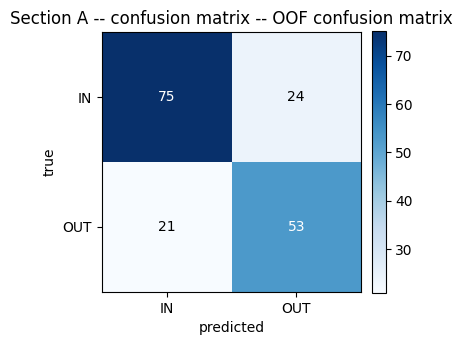

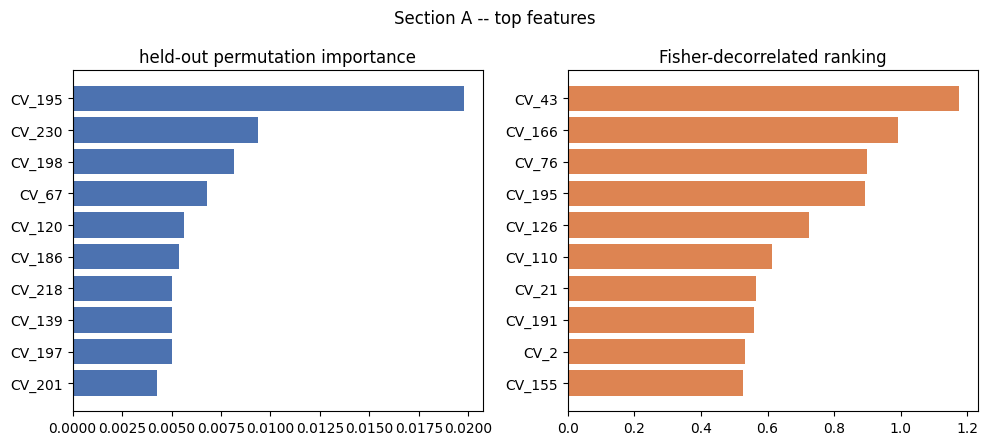

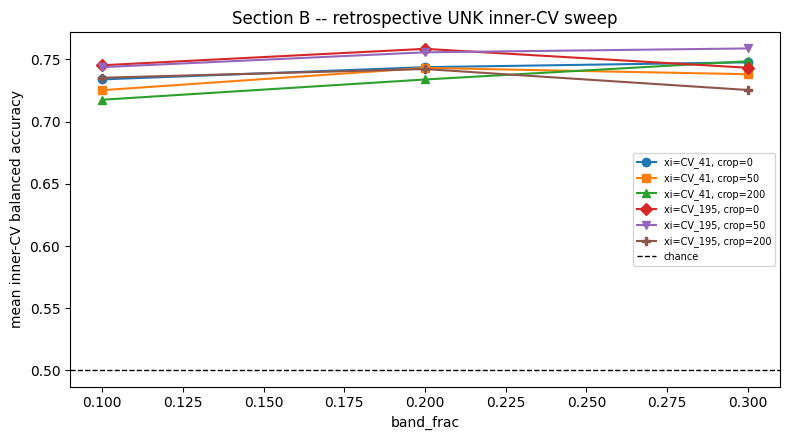

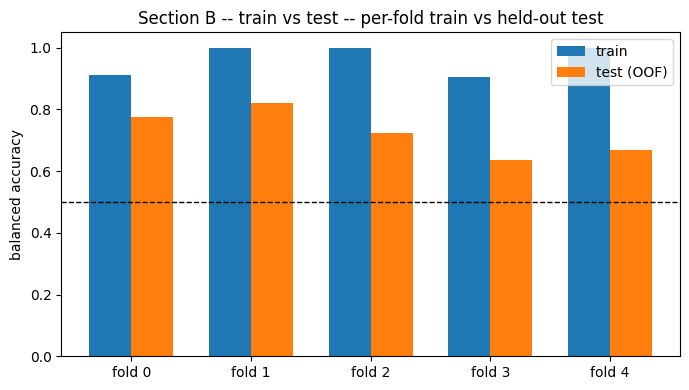

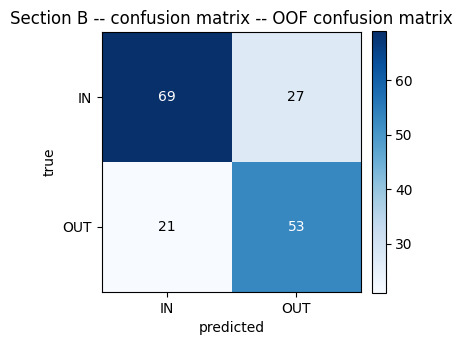

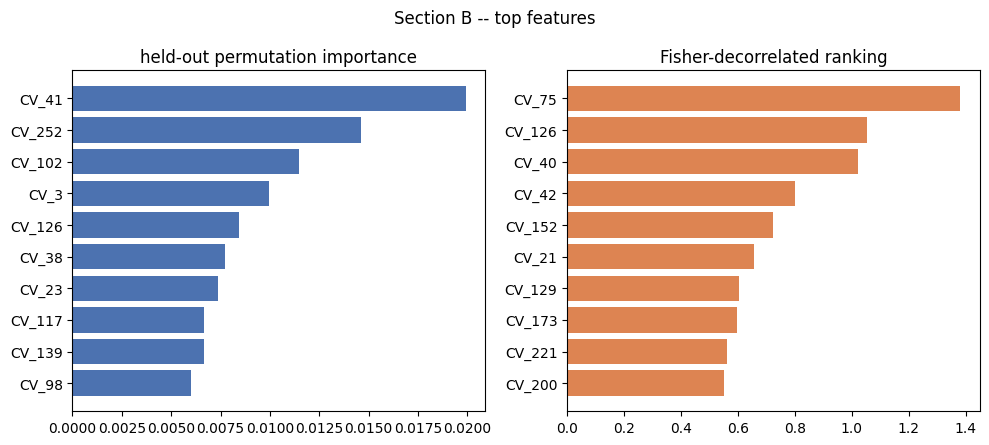

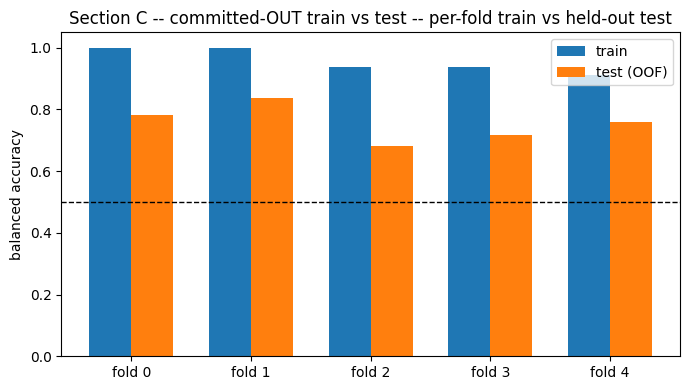

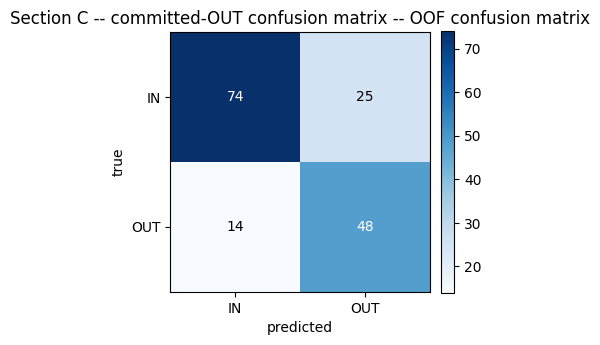

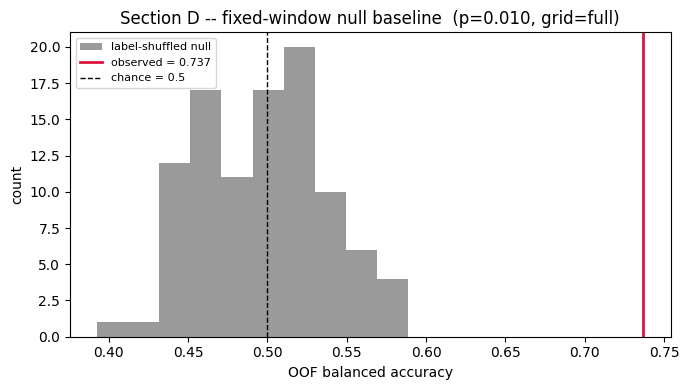

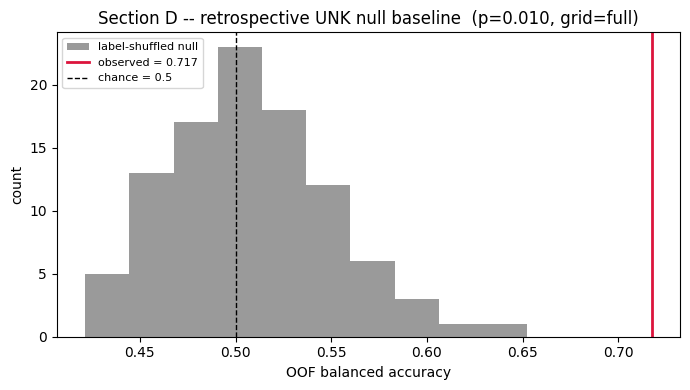

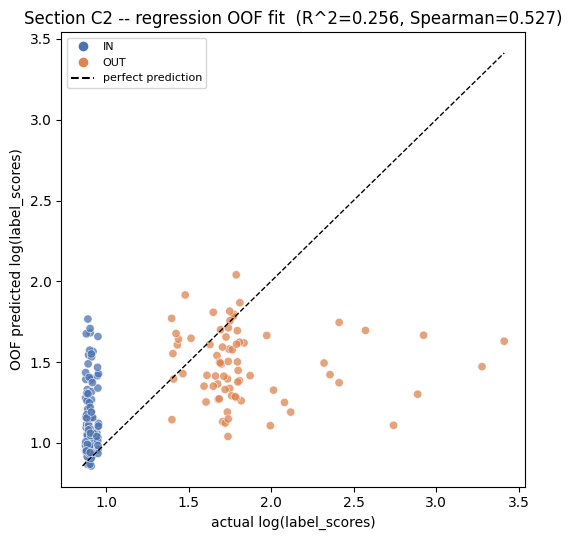

Figures also saved to: /mnt/data1/student/trypsin/yucheng/07.12/v4/plot_*.png


In [18]:
if SHOW_PLOTS:
    plot_window_sweep(fixed_result, "Section A -- fixed-window inner-CV sweep")
    plot_fold_train_test(fixed_result, "Section A -- train vs test")
    plot_confusion(fixed_result, "Section A -- confusion matrix")
    plot_top_features_comparison(
        fixed_result["top_heldout_permutation_features"],
        fixed_result["fisher_decorrelated_top_features"],
        "Section A -- top features",
    )

    if unk_result is not None:
        plot_unk_sweep(unk_result, "Section B -- retrospective UNK inner-CV sweep")
        plot_fold_train_test(unk_result, "Section B -- train vs test")
        plot_confusion(unk_result, "Section B -- confusion matrix")
        plot_top_features_comparison(
            unk_result["top_heldout_permutation_features"],
            unk_result["fisher_decorrelated_top_features"],
            "Section B -- top features",
        )

    if committed_result is not None:
        plot_fold_train_test(committed_result, "Section C -- committed-OUT train vs test")
        plot_confusion(committed_result, "Section C -- committed-OUT confusion matrix")

    plot_null_distribution(fixed_null, "Section D -- fixed-window null baseline")
    plot_null_distribution(unk_null, "Section D -- retrospective UNK null baseline")

    if regression_result is not None:
        plot_regression_scatter(regression_result, indices, "Section C2 -- regression OOF fit")

    print(f"Figures also saved to: {args.out_dir}/plot_*.png")

## Save and display the final summary

Includes the Section A headline result plus the Section C (class-definition sensitivity) and Section D (chance-baseline) checks, so the summary can't be read in isolation from its own robustness checks.


In [19]:
summary = {
    "fixed_window_oof_balanced_accuracy": fixed_result[
        "oof_balanced_accuracy"
    ],
    "fixed_window_95ci": fixed_result[
        "oof_balanced_accuracy_cluster_bootstrap_95ci"
    ],
    "fixed_window_selected_key_counts": fixed_result[
        "selected_key_counts"
    ],
    "fixed_window_top_features": fixed_result[
        "top_heldout_permutation_features"
    ],
    "retrospective_unk_oof_balanced_accuracy": (
        None
        if unk_result is None
        else unk_result["oof_balanced_accuracy"]
    ),
    "retrospective_unk_95ci": (
        None
        if unk_result is None
        else unk_result[
            "oof_balanced_accuracy_cluster_bootstrap_95ci"
        ]
    ),
    "retrospective_unk_selected_key_counts": (
        None
        if unk_result is None
        else unk_result["selected_key_counts"]
    ),
    "retrospective_unk_top_features": (
        None
        if unk_result is None
        else unk_result["top_heldout_permutation_features"]
    ),
    "committed_out_oof_balanced_accuracy": (
        None if committed_result is None else committed_result["oof_balanced_accuracy"]
    ),
    "committed_out_95ci": (
        None if committed_result is None
        else committed_result["oof_balanced_accuracy_cluster_bootstrap_95ci"]
    ),
    "committed_out_threshold": OUT_COMMITTED_THRESHOLD,
    "committed_out_n_dropped": (
        None if committed_result is None else committed_result["n_dropped_borderline_out"]
    ),
    "fixed_window_null_baseline": (
        None if fixed_null is None
        else {"mean": fixed_null["null_mean"], "std": fixed_null["null_std"],
              "p_value": fixed_null["p_value"]}
    ),
    "retrospective_unk_null_baseline": (
        None if unk_null is None
        else {"mean": unk_null["null_mean"], "std": unk_null["null_std"],
              "p_value": unk_null["p_value"]}
    ),
    "committed_out_borderline_out_of_sample": (
        None if committed_result is None
        else committed_result.get("borderline_out_of_sample")
    ),
    "label_score_regression_oof_r2": (
        None if regression_result is None else regression_result["oof_r2"]
    ),
    "label_score_regression_r2_95ci": (
        None if regression_result is None else regression_result["oof_r2_cluster_bootstrap_95ci"]
    ),
    "label_score_regression_spearman": (
        None if regression_result is None else regression_result["oof_spearman_correlation"]
    ),
    "label_score_regression_oof_mae_log_score": (
        None if regression_result is None else regression_result["oof_mae_log_label_score"]
    ),
    "label_score_regression_top_features": (
        None if regression_result is None else regression_result["top_heldout_permutation_features"]
    ),
    "fisher_decorrelation_enabled": RUN_FISHER_DECORRELATION,
    "fixed_window_fisher_decorrelated_top_features": fixed_result["fisher_decorrelated_top_features"],
    "retrospective_unk_fisher_decorrelated_top_features": (
        None if unk_result is None else unk_result["fisher_decorrelated_top_features"]
    ),
    "null_baseline_candidate_grid": "full" if NULL_USE_FULL_GRID else "narrow",
    "fisher_correlation_reference": (
        "Outer-fold held-out, fold-selected window/config feature matrices; "
        "absolute correlations averaged only where both CVs were present."
    ),
    "regression_split_strategy": (
        "StratifiedGroupKFold on rank-quantile bins of group-level log(label_scores), "
        "with shuffled grouped fallback for undersized datasets."
    ),
    "candidate_grid_provenance_caveat": metadata["candidate_grid_provenance_caveat"],
    "elapsed_seconds": round(time.time() - started, 1),
    "reporting_rule": (
        "Use nested out-of-fold metrics for performance; "
        "use the full-data model only for deployment/refit. Compare the Section A "
        "result against Section C (class-definition sensitivity), Section C2 "
        "(regression reframing), and Section D (chance baseline) before treating "
        "it as a finding."
    ),
}
save_json(os.path.join(args.out_dir, "summary.json"), summary)

print(f"Outputs saved in: {args.out_dir}")
summary


Outputs saved in: /mnt/data1/student/trypsin/yucheng/07.12/v4


{'fixed_window_oof_balanced_accuracy': 0.7368959868959869,
 'fixed_window_95ci': [0.6677019953221278, 0.7999270140428677],
 'fixed_window_selected_key_counts': {'w_2090_2289': 1,
  'w_2263_2272': 1,
  'w_2490_2499': 1,
  'w_2450_2499': 1,
  'w_2037_2046': 1},
 'fixed_window_top_features': [{'rank': 1,
   'index': 195,
   'name': 'CV_195',
   'importance': 0.01976089188589187,
   'max_abs_corr_with_higher_ranked': None,
   'likely_redundant_with': None},
  {'rank': 2,
   'index': 230,
   'name': 'CV_230',
   'importance': 0.009392857142857139,
   'max_abs_corr_with_higher_ranked': None,
   'likely_redundant_with': None},
  {'rank': 3,
   'index': 198,
   'name': 'CV_198',
   'importance': 0.008142857142857132,
   'max_abs_corr_with_higher_ranked': 0.8687482766846756,
   'likely_redundant_with': 'CV_195'},
  {'rank': 4,
   'index': 67,
   'name': 'CV_67',
   'importance': 0.006769841269841273,
   'max_abs_corr_with_higher_ranked': None,
   'likely_redundant_with': None},
  {'rank': 5,
  